<a href="https://www.kaggle.com/code/shoshanamiriamlevin/dollar-ils-by-yaakov-levin?scriptVersionId=347564505" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        path=os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
from rich import print
from rich.panel import Panel

print(Panel(
    "[bold cyan]Business Problem[/bold cyan]\n"
    "Companies in Israel that import or export goods face significant exposure to the USD/ILS exchange rate.\n"
    "[yellow]Daily fluctuations of 0.3%–0.6% can materially impact margins, cash flow, and hedging costs.[/yellow]",
    title="USD/ILS FX Risk",
    border_style="bright_blue"
))

╭──────────────────────────────────────────────── USD/ILS FX Risk ────────────────────────────────────────────────╮
│ Business Problem                                                                                                │
│ Companies in Israel that import or export goods face significant exposure to the USD/ILS exchange rate.         │
│ Daily fluctuations of 0.3%–0.6% can materially impact margins, cash flow, and hedging costs.                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

we make this dataset from yahoo finance we chose to only use the data for the past year even though it has 5 years because the the usd ils changed over the past year and I didn't bring greed index for more time 

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
warnings.simplefilter("ignore")

In [5]:
df=pd.read_csv(path)
df.tail()

,Date,USDILS,US10Y,OIL,GOLD,EURILS,SNP500,NASDAQ100,Fear_Greed
1663,2026-05-25,2.88996,4.558,96.599998,4521.000000,3.155900,7473.470215,29481.640625,58.971429
1664,2026-05-26,2.88012,4.493,93.889999,4500.399902,3.353110,7519.120117,30001.320312,60.914286
1665,2026-05-27,2.84112,4.481,88.680000,4447.500000,3.302783,7520.359863,29973.570312,60.600000
1666,2026-05-28,2.82636,4.455,88.900002,4499.299805,3.285892,7563.629883,30223.890625,60.085714
1667,2026-05-29,2.82166,4.453,87.360001,4560.500000,3.286580,7580.060059,30333.179688,59.171429


In [6]:
df_new=df.dropna()
df_new.head()

,Date,USDILS,US10Y,OIL,GOLD,EURILS,SNP500,NASDAQ100,Fear_Greed
1410,2025-06-02,3.51754,4.462,62.520000,3370.600098,3.9915,5935.939941,21491.750000,62.428571
1411,2025-06-03,3.52690,4.460,63.410000,3350.199951,4.0224,5970.370117,21662.580078,54.571429
1412,2025-06-04,3.51894,4.365,62.849998,3373.500000,4.0009,5970.810059,21721.919922,54.885714
1413,2025-06-05,3.48356,4.394,63.369999,3350.699951,3.9779,5939.299805,21547.429688,57.971429
1414,2025-06-06,3.49088,4.510,64.580002,3322.699951,3.9936,6000.359863,21761.789062,61.771429


In [7]:
df_new.columns

Index(['Date', 'USDILS', 'US10Y', 'OIL', 'GOLD', 'EURILS', 'SNP500',
       'NASDAQ100', 'Fear_Greed'],
      dtype='object')

In [8]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 258 entries, 1410 to 1667
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        258 non-null    object 
 1   USDILS      258 non-null    float64
 2   US10Y       258 non-null    float64
 3   OIL         258 non-null    float64
 4   GOLD        258 non-null    float64
 5   EURILS      258 non-null    float64
 6   SNP500      258 non-null    float64
 7   NASDAQ100   258 non-null    float64
 8   Fear_Greed  258 non-null    float64
dtypes: float64(8), object(1)
memory usage: 20.2+ KB


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns 
import re

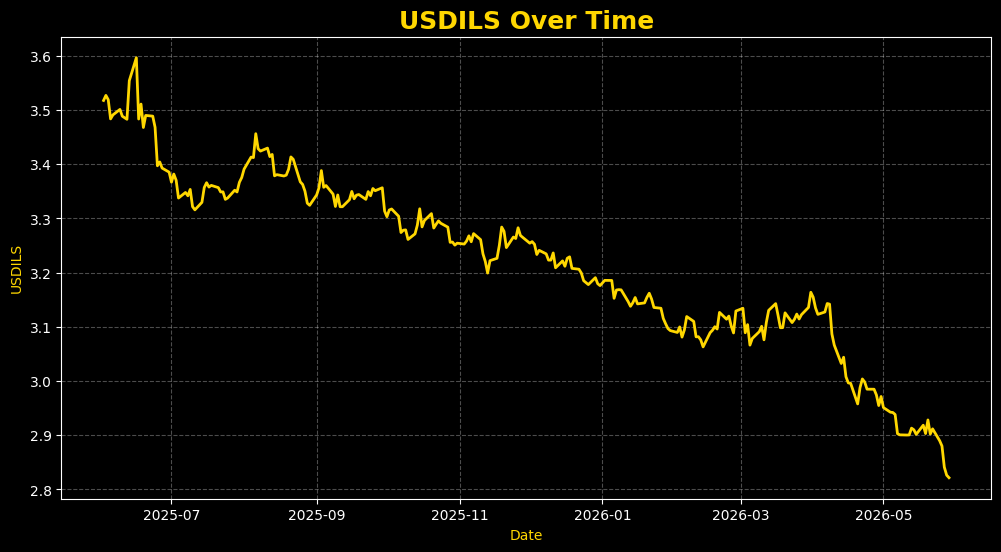

In [10]:
df_new = df_new.copy()
df_new['Date'] = pd.to_datetime(df_new['Date'])

plt.style.use("dark_background")  # black background

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_new,
    x="Date",
    y="USDILS",
    color="#FFD700",      # gold
    linewidth=2
)

plt.title("USDILS Over Time", fontsize=18, weight="bold", color="#FFD700")
plt.xlabel("Date", color="#FFD700")
plt.ylabel("USDILS", color="#FFD700")

plt.grid(True, linestyle="--", alpha=0.3)

safe_filename = re.sub(r"[^A-Za-z0-9_]+", "_", "USDILS Over Time") + ".png"
plt.savefig(safe_filename, dpi=300, bbox_inches="tight")

plt.show()

In [11]:
colunms=['US10Y','GOLD','EURILS','SNP500','NASDAQ100']

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

def scatter_with_corr(df, x, y):
    # Set gold/black style
    plt.style.use('dark_background')
    
    # Custom colors
    gold = '#FFD700'
    light_gold = '#FFC125'
    silver_gold = '#DAA520'  # for regression line
    
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')
    
    # Scatterplot – golden points with dark edges
    sns.scatterplot(data=df, x=x, y=y, s=60, 
                    color=gold, edgecolor='black', linewidth=0.5, ax=ax)
    
    # Regression line (golden, slightly thinner)
    sns.regplot(data=df, x=x, y=y, scatter=False, 
                color=light_gold, line_kws={"linewidth": 2}, ax=ax)
    
    # Mean reference lines (dashed, gold)
    ax.axhline(df[y].mean(), color=gold, linestyle="--", linewidth=1, alpha=0.7)
    ax.axvline(df[x].mean(), color=gold, linestyle="--", linewidth=1, alpha=0.7)
    
    # Titles and labels in gold
    main_title = f"Relationship Between {x} and {y}"
    ax.set_title(main_title, fontsize=16, weight="bold", color=gold)
    
    # Subtitle with correlation
    corr_xy = df[[x, y]].corr().iloc[0, 1]
    ax.text(0.5, 0.96, f"Correlation ({x}, {y}) = {corr_xy:.4f}",
            transform=ax.transAxes, ha='center', va='center',
            fontsize=10, color=gold, weight='medium')
    
    # Axis labels and ticks in gold
    ax.set_xlabel(x, color=gold, fontsize=12)
    ax.set_ylabel(y, color=gold, fontsize=12)
    ax.tick_params(colors=gold)
    
    # Spines in gold
    for spine in ax.spines.values():
        spine.set_edgecolor(gold)
    
    plt.tight_layout()
    
    # Safe filename
    safe_filename = re.sub(r'[^A-Za-z0-9_]+', '_', main_title) + ".png"
    plt.savefig(safe_filename, dpi=300, bbox_inches="tight", facecolor='black')
    plt.show()
    
    return safe_filename

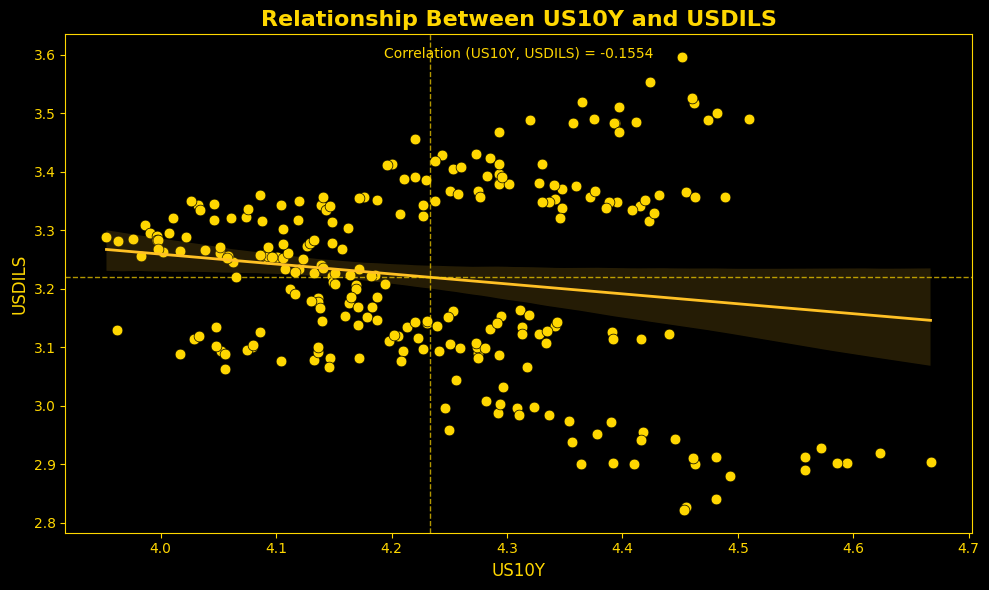

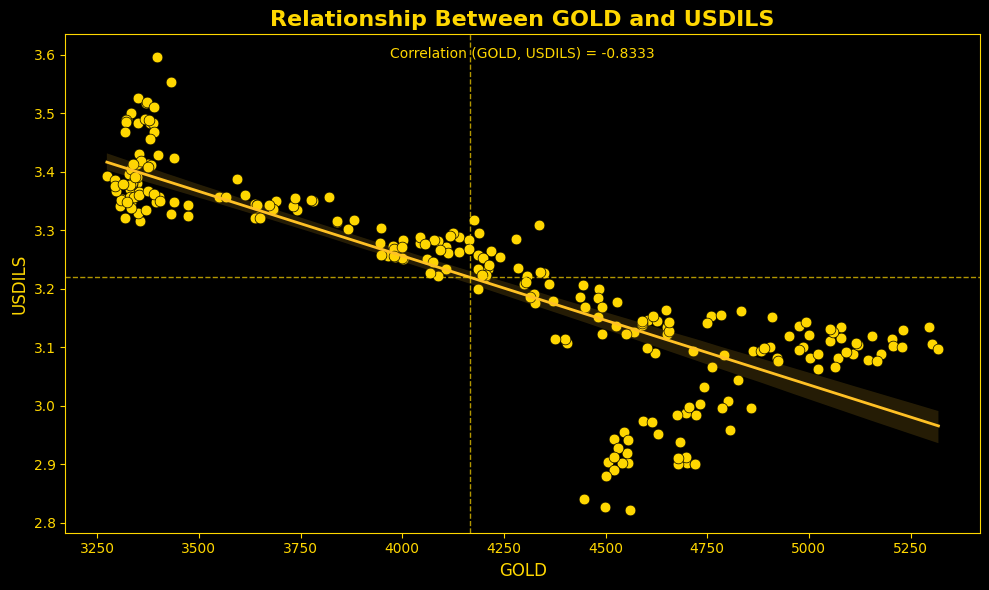

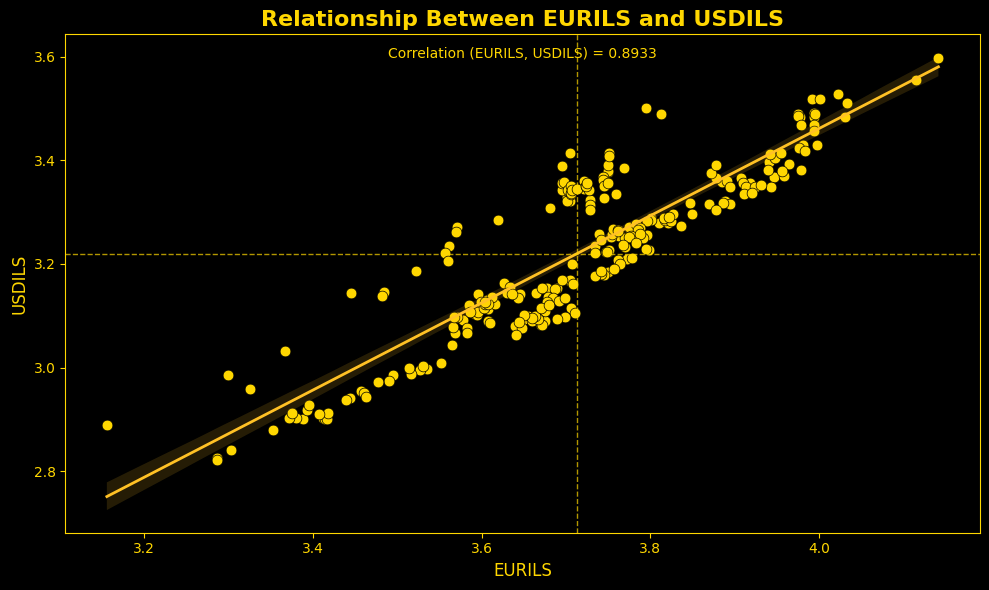

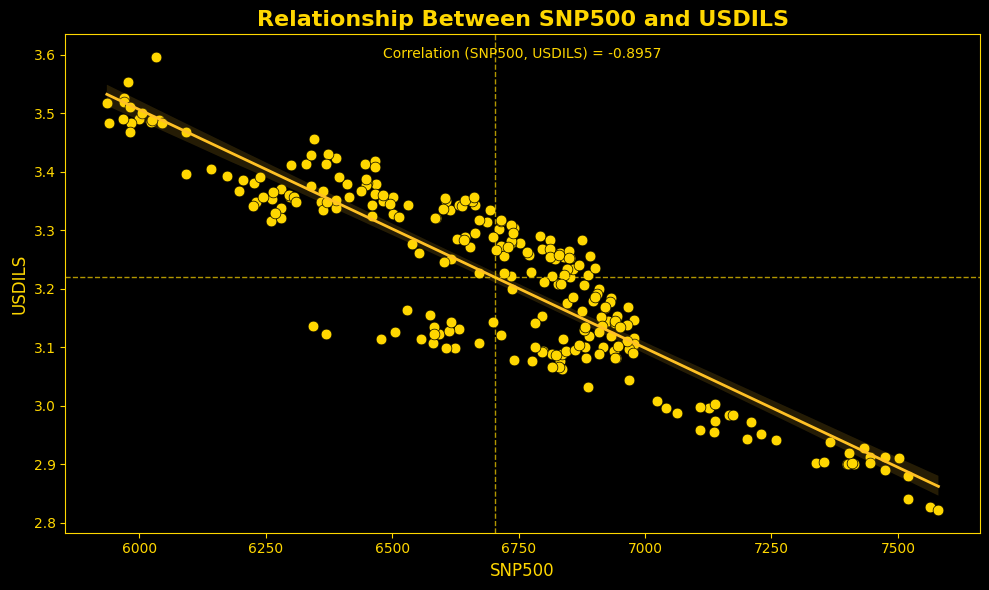

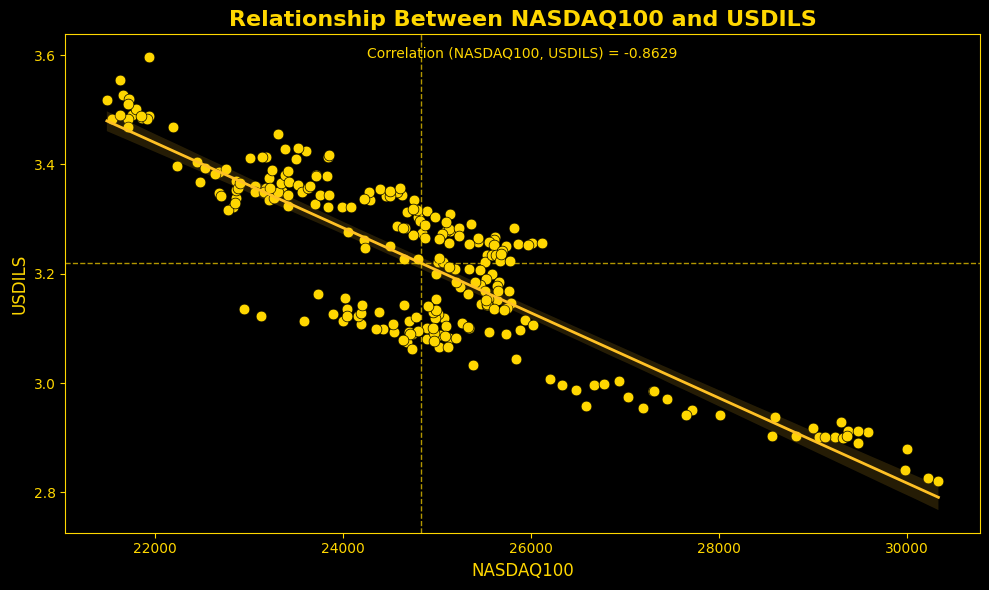

In [13]:
for c in colunms :
    scatter_with_corr(df_new,c,'USDILS')

In [14]:
import statsmodels.formula.api as smf

model1 = smf.ols("USDILS ~ US10Y + OIL + GOLD + EURILS + SNP500 + NASDAQ100 + Fear_Greed", data=df_new).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 USDILS   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     827.9
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          5.73e-169
Time:                        20:27:28   Log-Likelihood:                 515.15
No. Observations:                 258   AIC:                            -1014.
Df Residuals:                     250   BIC:                            -985.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.6138      0.275     20.396      0.000       5.072       6.156
US10Y         -0.1732      0.027     -6.523      0.000      -0.225      -0.121
OIL           -0.0016      0.000     -6.241      0.000      -0.002      -0.001
GOLD       -7.675e-05   9.22e-06     -8.320      0.000   -9.49e-05   -5.86e-05
EURILS         0.1382      0.028      4.900      0.000       0.083       0.194
SNP500        -0.0003    5.9e-05     -5.773      0.000      -0.000      -0.000
NASDAQ100   2.165e-05   9.67e-06      2.238      0.026     2.6e-06    4.07e-05
Fear_Greed     0.0002      0.000      0.932      0.352      -0.000       0.000
==============================================================================
Omnibus:                        1.675   Durbin-Watson:                   0.659
Prob(Omnibus):                  0.433   Jarque-Bera (JB):                1.433
Skew:                          -0.060   Prob(JB):                        0.488
Kurtosis:                       3.345   Cond. No.                     3.48e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.48e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

📉 What the Regression Really Shows (in simple language)S&P 500When the S&P 500 goes up, the USD/ILS goes down.
That suggests that when global markets are strong, investors may also feel more confident about Israel’s economy. Money flows into Israel, strengthening the shekel
US 10‑Year BondsA surprising result is that when US10Y yields go down, the USD/ILS alsoconnects to the strong effect of the 
EUR/ILSThe EURILS variable has a strong positive effect.
This basically tells us:
When the euro strengthens against the shekel, the dollar tends to strengthen too.
So part of the USD/ILS movement is really about the shekel itself, not the dollar.
OilAs oil prices rise, the USD/ILS goes down.
That might reflect Israel’s economy being less sensitive to oil shocks than in the past, or global risk sentiment improving when oil rises.GoldHigher gold prices also push the USD/ILS down, although the effect is small.
Gold usually rises when investors are nervous, but here the pattern suggests that shekel strength has been the dominant force, overpowering the usual “risk‑off” behavior.
🧠 The Big PictureAcross the board, many global indicators point in the same direction:
The shekel has been unusually strong this past year, and that strength shows up in almost every variable — stocks, bonds, oil, gold, and the euro.

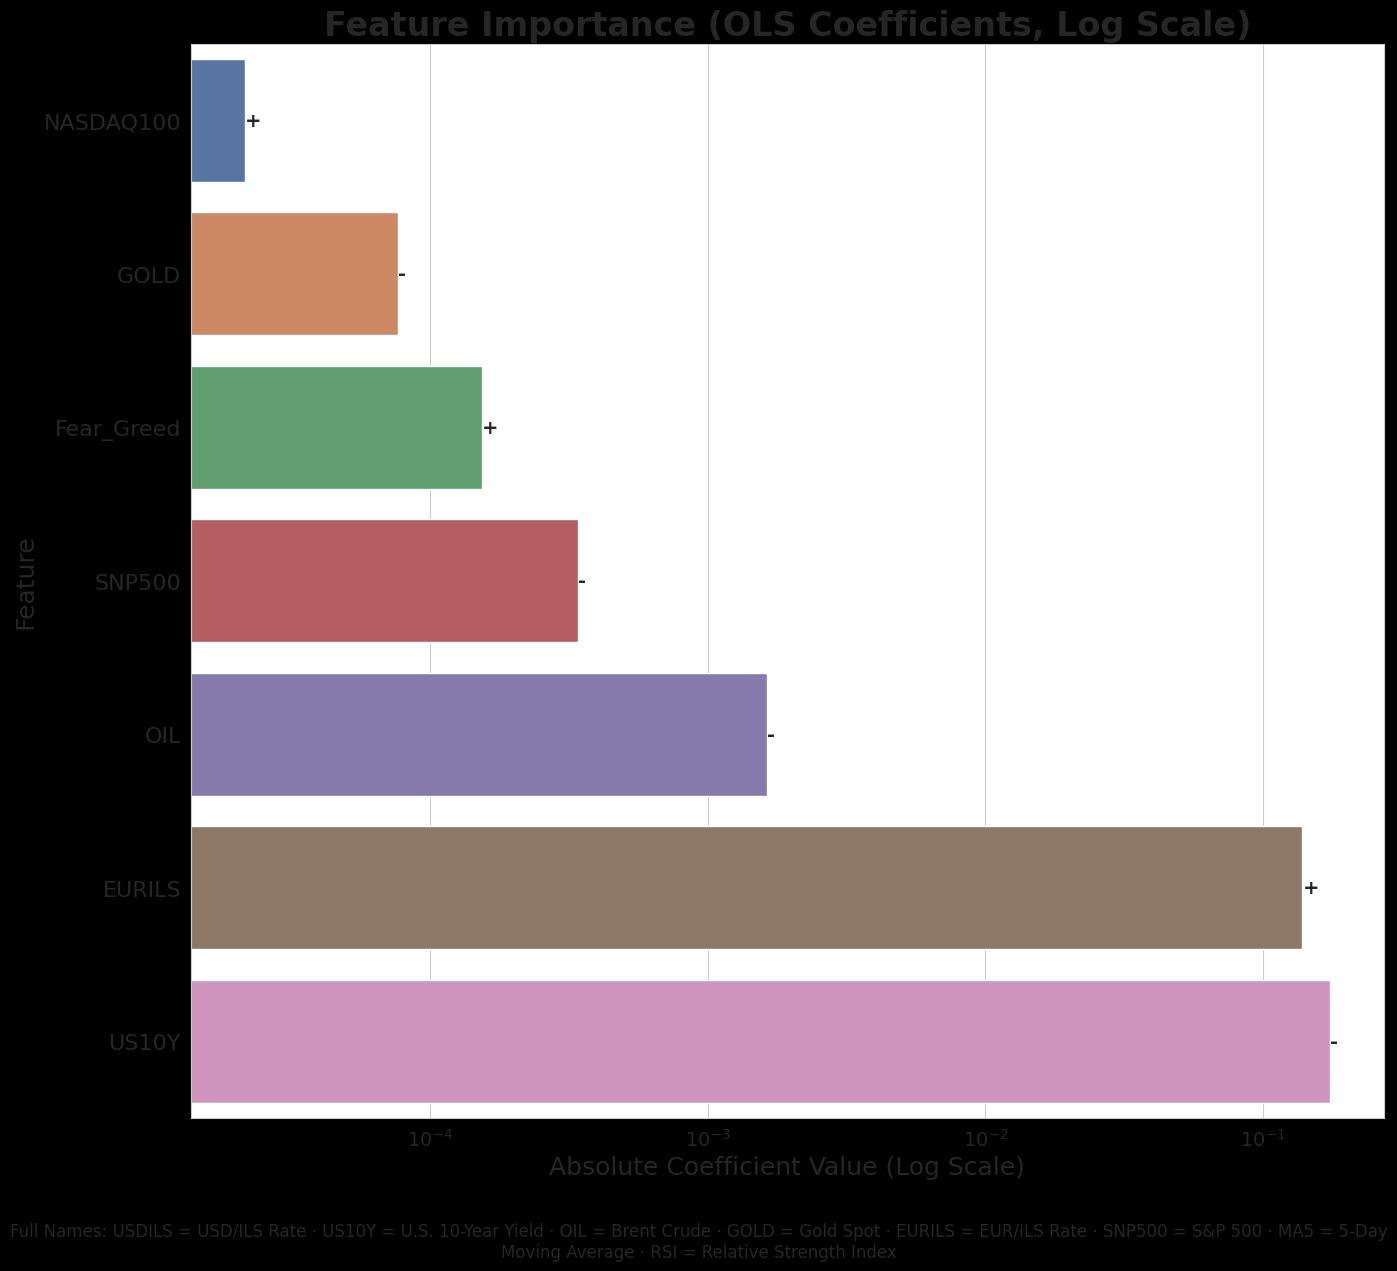

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Extract coefficients (excluding intercept)
coef = model1.params.drop("Intercept")

# Use absolute values for log scale, but keep sign separately
coef_abs = coef.abs()
coef_sign = np.sign(coef)

# Sort by absolute value
coef_sorted = coef_abs.reindex(coef_abs.sort_values(ascending=True).index)
coef_sign_sorted = coef_sign.loc[coef_sorted.index]

plt.figure(figsize=(14, 12))
sns.set_style("whitegrid")

# Horizontal bar plot using absolute values
sns.barplot(
    x=coef_sorted.values,
    y=coef_sorted.index,
    palette="deep"
)

# Apply log scale
plt.xscale("log")

# Reapply signs as text labels
for i, (val, sign) in enumerate(zip(coef_sorted.values, coef_sign_sorted.values)):
    plt.text(
        val,
        i,
        f"{'+' if sign > 0 else '-'}",
        va="center",
        ha="left",
        fontsize=14,
        weight="bold"
    )

plt.title("Feature Importance (OLS Coefficients, Log Scale)", fontsize=24, weight="bold")
plt.xlabel("Absolute Coefficient Value (Log Scale)", fontsize=18)
plt.ylabel("Feature", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=16)

# Caption with full names
plt.figtext(
    0.5, -0.05,
    "Full Names: USDILS = USD/ILS Rate · US10Y = U.S. 10-Year Yield · OIL = Brent Crude · GOLD = Gold Spot · "
    "EURILS = EUR/ILS Rate · SNP500 = S&P 500 · MA5 = 5-Day Moving Average · RSI = Relative Strength Index",
    wrap=True, ha="center", fontsize=12
)

plt.tight_layout()
plt.savefig('the_biggest_drives_ols.png',dpi=400)
plt.show()

In [16]:
df_pct = df_new.set_index("Date").pct_change().dropna()

In [17]:
df_pct.tail()

,USDILS,US10Y,OIL,GOLD,EURILS,SNP500,NASDAQ100,Fear_Greed
Date,,,,,,,,
2026-05-25,-0.007507,0.000000,0.000000,0.000000,-0.065102,0.000000,0.000000,0.000000
2026-05-26,-0.003405,-0.014261,-0.028054,-0.004557,0.062489,0.006108,0.017627,0.032946
2026-05-27,-0.013541,-0.002671,-0.055490,-0.011754,-0.015009,0.000165,-0.000925,-0.005159
2026-05-28,-0.005195,-0.005802,0.002481,0.011647,-0.005114,0.005754,0.008351,-0.008487
2026-05-29,-0.001663,-0.000449,-0.017323,0.013602,0.000209,0.002172,0.003616,-0.015216


In [18]:
import statsmodels.formula.api as smf

model2 = smf.ols(
    "USDILS ~ US10Y + OIL + GOLD + EURILS + SNP500 + NASDAQ100 + Fear_Greed",
    data=df_pct
).fit()

model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 USDILS   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     2.028
Date:                Sat, 05 Sep 2026   Prob (F-statistic):             0.0522
Time:                        20:27:31   Log-Likelihood:                 955.62
No. Observations:                 257   AIC:                            -1895.
Df Residuals:                     249   BIC:                            -1867.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0009      0.000     -2.440      0.015      -0.002      -0.000
US10Y          0.0193      0.043      0.450      0.653      -0.065       0.104
OIL            0.0022      0.014      0.163      0.871      -0.025       0.029
GOLD           0.0422      0.023      1.811      0.071      -0.004       0.088
EURILS         0.0549      0.017      3.194      0.002       0.021       0.089
SNP500         0.0523      0.171      0.305      0.761      -0.285       0.390
NASDAQ100      0.0019      0.120      0.015      0.988      -0.235       0.238
Fear_Greed -7.604e-05      0.003     -0.030      0.976      -0.005       0.005
==============================================================================
Omnibus:                       26.170   Durbin-Watson:                   2.237
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               51.786
Skew:                          -0.533   Prob(JB):                     5.68e-12
Kurtosis:                       4.924   Cond. No.                         552.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

#1 make y

y = df_new['USDILS'] 

# 2. Define the independent variables from your image
features = ['US10Y', 'OIL', 'GOLD', 'EURILS', 'SNP500', 'NASDAQ100', 'Fear_Greed']
X = df_new[features]
X_with_intercept = sm.add_constant(X)

# 3. TEST 1: Calculate VIF to see if S&P500 is "stealing" the signal
vif_data = pd.DataFrame()
vif_data["Variable"] = X_with_intercept.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_intercept.values, i) for i in range(X_with_intercept.shape[1])]

print("--- VARIANCE INFLATION FACTOR (VIF) RESULTS ---")
print(vif_data.to_string(index=False))
print("\n*Note: Any VIF score above 5.0 to 10.0 confirms severe signal stealing.*\n")

# 4. TEST 2: Run a simple regression with ONLY the 10-Year Bond
print("--- US10Y SINGLE VARIABLE REGRESSION ---")
X_single = sm.add_constant(df_new[['US10Y']])
single_model = sm.OLS(y, X_single).fit()
print(f"Isolated US10Y Coefficient: {single_model.params['US10Y']:.4f}")
print(f"Isolated US10Y P-value: {single_model.pvalues['US10Y']:.4f}")


--- VARIANCE INFLATION FACTOR (VIF) RESULTS ---

Variable          VIF
     const 17544.493370
     US10Y     3.571838
       OIL     3.782909
      GOLD     7.340568
    EURILS     5.419334
    SNP500   101.501811
 NASDAQ100    69.463389
Fear_Greed     2.201778

*Note: Any VIF score above 5.0 to 10.0 confirms severe signal stealing.*

--- US10Y SINGLE VARIABLE REGRESSION ---

Isolated US10Y Coefficient: -0.1697

Isolated US10Y P-value: 0.0125

it seems to be snp500 and nasdaq are basically the same 

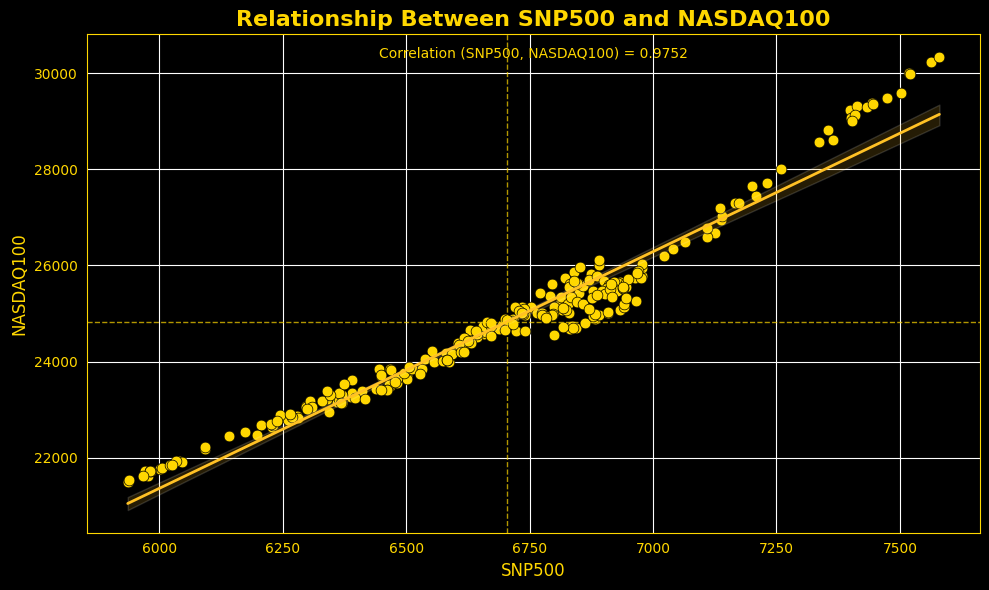

'Relationship_Between_SNP500_and_NASDAQ100.png'

In [20]:
scatter_with_corr(df_new,'SNP500','NASDAQ100')

In [21]:
df1=df.copy()

In [22]:
df=df_new.copy()

we see there is a very big connection between snp500 and nasdaq100 over the past year

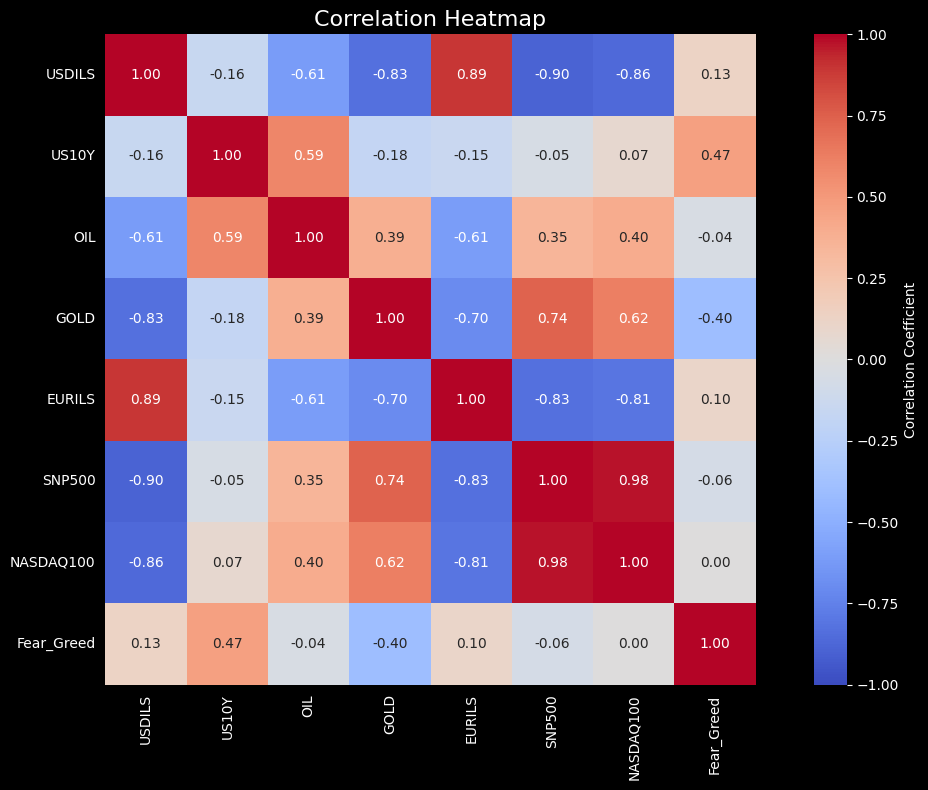

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Compute correlation matrix
df_no_date = df.drop(columns=["Date"])
corr = df_no_date.corr()

# 2. Set figure size
plt.figure(figsize=(12, 8))

# 3. Plot heatmap
sns.heatmap(
    corr,
    annot=True,        # show correlation values
    fmt=".2f",         # two decimal places
    cmap="coolwarm",   # diverging palette
    vmin=-1, vmax=1,   # full correlation range
    square=True,       # make cells square
    cbar_kws={"label": "Correlation Coefficient"}
)

# 4. Title + layout
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()

# 5. Save high-resolution
plt.savefig("correlation_heatmap.png", dpi=400, bbox_inches="tight")
plt.show()

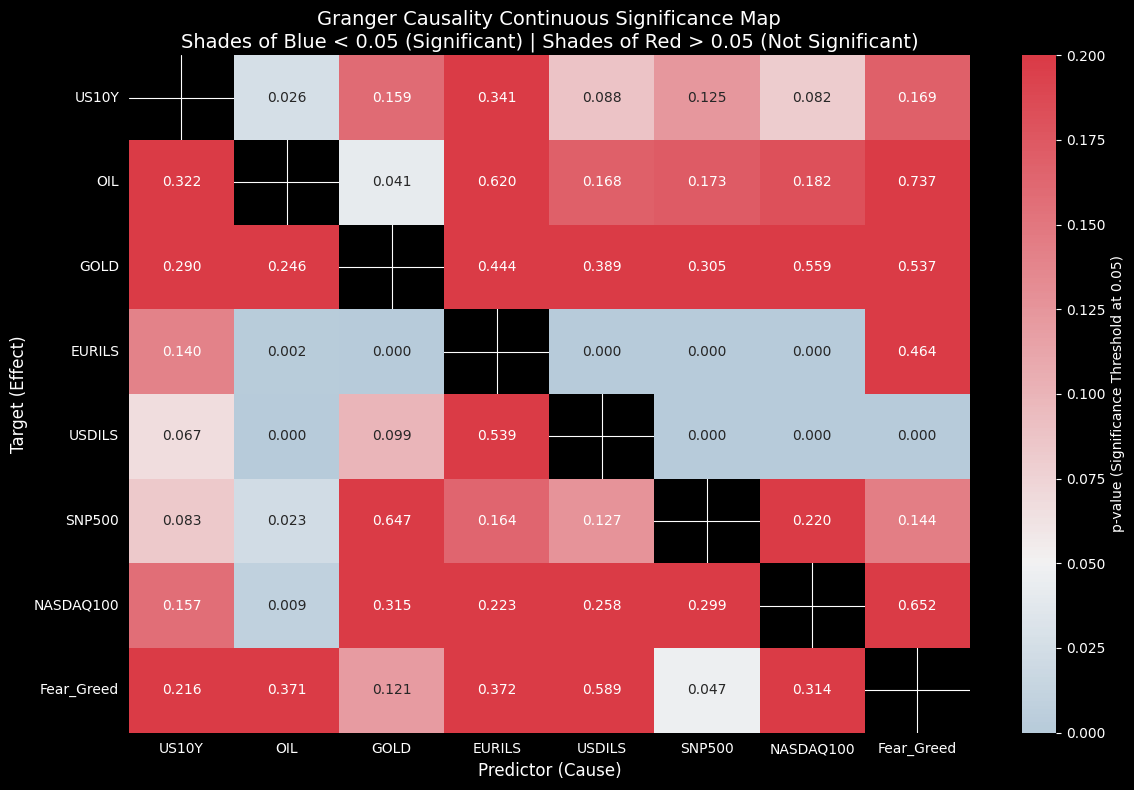

<Figure size 1200x800 with 0 Axes>

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests

# -----------------------------
# VARIABLES IN YOUR VAR MODEL
# -----------------------------
variables = ["US10Y", "OIL", "GOLD", "EURILS", "USDILS", "SNP500", "NASDAQ100", "Fear_Greed"]

# df must contain these columns
# df = your_dataframe 

maxlag = 4  

# -----------------------------------
# FUNCTION TO GET MINIMUM P-VALUE
# -----------------------------------
def granger_pvalue(cause, effect):
    try:
        # Note: statsmodels expects [effect, cause] as columns
        test = grangercausalitytests(df[[effect, cause]], maxlag=maxlag, verbose=False)
        pvals = [test[i+1][0]['ssr_chi2test'][1] for i in range(maxlag)]
        return np.min(pvals)
    except Exception as e:
        return np.nan

# -----------------------------------
# BUILD P-VALUE MATRIX
# -----------------------------------
p_matrix = pd.DataFrame(np.zeros((len(variables), len(variables))),
                        columns=variables, index=variables)

for cause in variables:
    for effect in variables:
        if cause != effect:
            p_matrix.loc[effect, cause] = granger_pvalue(cause, effect)
        else:
            p_matrix.loc[effect, cause] = np.nan

# -----------------------------------
# GRADIENT COLOR MAP SETUP
# -----------------------------------
plt.figure(figsize=(12, 8))

# Creates a continuous gradient: Blue on the low end, Red on the high end
# center="light" creates a neutral transition point between the colors
gradient_cmap = sns.diverging_palette(240, 10, as_cmap=True, center="light")

sns.heatmap(
    p_matrix,
    annot=True,          # Prints the explicit p-value text on every square
    cmap=gradient_cmap,
    fmt=".3f",           # Forces numbers to display with 3 decimal places
    center=0.05,         # CRITICAL: Forces the color shift boundary to lock at p = 0.05
    vmin=0.00,           # Deepest blue represents a p-value of 0
    vmax=0.20,           # Deepest red represents any p-value at or above 0.20
    cbar_kws={'label': 'p-value (Significance Threshold at 0.05)'}
)

plt.title("Granger Causality Continuous Significance Map\nShades of Blue < 0.05 (Significant) | Shades of Red > 0.05 (Not Significant)", fontsize=14)
plt.xlabel("Predictor (Cause)", fontsize=12)
plt.ylabel("Target (Effect)", fontsize=12)
plt.tight_layout()
plt.figure(figsize=(12, 8))
plt.savefig("granger_causality_significance_matrix.png", dpi=280, bbox_inches="tight")
plt.show()


In [25]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

# Copy dataframe
df_std = df_new.copy()

# Predictors (NASDAQ100 removed)
features = ["US10Y", "OIL", "GOLD", "EURILS", "SNP500", "Fear_Greed"]

# Standardize predictors
scaler = StandardScaler()
df_std[features] = scaler.fit_transform(df_std[features])

# Rebuild OLS model without NASDAQ100
model3 = smf.ols(
    formula="USDILS ~ US10Y + OIL + GOLD + EURILS + SNP500 + Fear_Greed",
    data=df_std
).fit()
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 USDILS   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     949.8
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.12e-169
Time:                        20:27:38   Log-Likelihood:                 512.59
No. Observations:                 258   AIC:                            -1011.
Df Residuals:                     251   BIC:                            -986.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.2197      0.002   1537.220      0.000       3.216       3.224
US10Y         -0.0220      0.004     -6.099      0.000      -0.029      -0.015
OIL           -0.0226      0.004     -5.799      0.000      -0.030      -0.015
GOLD          -0.0562      0.004    -14.726      0.000      -0.064      -0.049
EURILS         0.0261      0.005      5.474      0.000       0.017       0.035
SNP500        -0.0751      0.005    -16.426      0.000      -0.084      -0.066
Fear_Greed     0.0003      0.003      0.098      0.922      -0.005       0.006
==============================================================================
Omnibus:                        1.267   Durbin-Watson:                   0.656
Prob(Omnibus):                  0.531   Jarque-Bera (JB):                0.999
Skew:                          -0.001   Prob(JB):                        0.607
Kurtosis:                       3.305   Cond. No.                         5.22
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The OLS model examined how several macro‑financial variables relate to USDILS levels.
The model achieved an Adjusted R² of 0.957, indicating an extremely strong in‑sample fit.Key Significant PredictorsUS10Y, OIL, GOLD, SNP500 → all negative and highly significantEURILS, NASDAQ100 → positive and significantFear_Greed → not significant in the OLS frameworkInterpretationThe OLS model captures static, cross‑sectional relationships, showingthat USDILS is strongly associated with global macro indicators.
However, OLS does not account for time‑series structure, autocorrelation, or volatility.

In [26]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

# Copy dataframe
df_std = df_new.copy()

# Predictors (Fear_Greed removed)
features = ["US10Y", "OIL", "GOLD", "EURILS", "SNP500"]

# Standardize predictors
scaler = StandardScaler()
df_std[features] = scaler.fit_transform(df_std[features])

# Build model4 without Fear_Greed
model4 = smf.ols(
    formula="USDILS ~ US10Y + OIL + GOLD + EURILS + SNP500",
    data=df_std
).fit()
model4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 USDILS   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     1144.
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          5.99e-171
Time:                        20:27:38   Log-Likelihood:                 512.58
No. Observations:                 258   AIC:                            -1013.
Df Residuals:                     252   BIC:                            -991.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.2197      0.002   1540.250      0.000       3.216       3.224
US10Y         -0.0218      0.003     -7.046      0.000      -0.028      -0.016
OIL           -0.0228      0.004     -6.083      0.000      -0.030      -0.015
GOLD          -0.0563      0.004    -15.778      0.000      -0.063      -0.049
EURILS         0.0261      0.005      5.487      0.000       0.017       0.035
SNP500        -0.0750      0.004    -17.164      0.000      -0.084      -0.066
==============================================================================
Omnibus:                        1.255   Durbin-Watson:                   0.657
Prob(Omnibus):                  0.534   Jarque-Bera (JB):                0.986
Skew:                          -0.001   Prob(JB):                        0.611
Kurtosis:                       3.303   Cond. No.                         5.17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

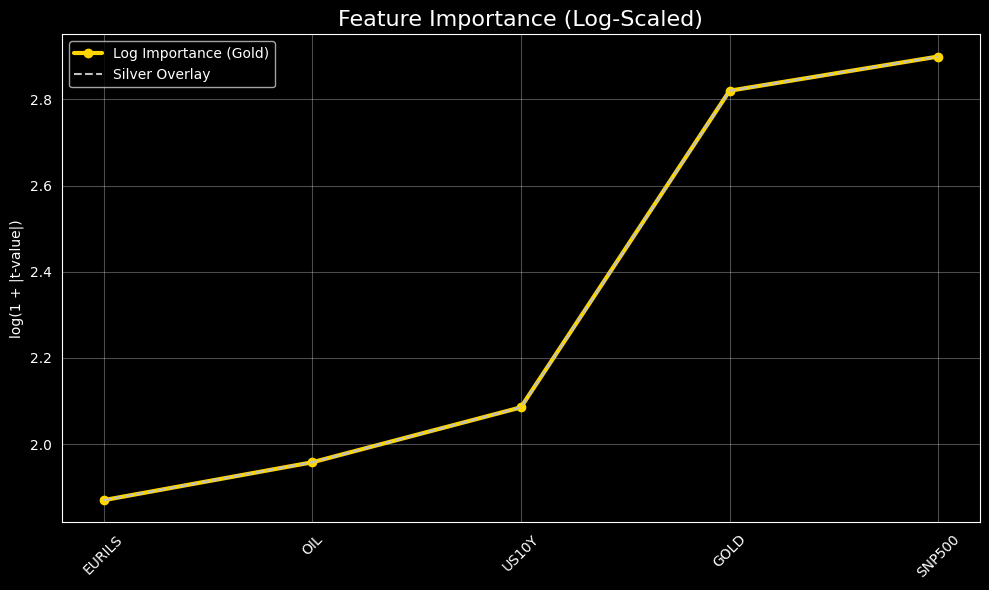

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Extract absolute t-values as feature importance
importance = model4.tvalues.drop("Intercept").abs()

# Log-transform to prevent domination by large values
importance_log = np.log1p(importance)

# Sort for nicer plotting
importance_log = importance_log.sort_values()

plt.style.use("dark_background")
plt.figure(figsize=(10, 6))

# Gold line
plt.plot(
    importance_log.index,
    importance_log.values,
    color="#FFD700", linewidth=3, marker="o", label="Log Importance (Gold)"
)

# Silver line
plt.plot(
    importance_log.index,
    importance_log.values,
    color="#C0C0C0", linewidth=1.5, linestyle="--", label="Silver Overlay"
)

plt.title("Feature Importance (Log-Scaled)", color="white", fontsize=16)
plt.ylabel("log(1 + |t-value|)", color="white")
plt.xticks(rotation=45, color="white")
plt.yticks(color="white")
plt.grid(alpha=0.3)

plt.legend()
plt.tight_layout()
plt.savefig('the_drivers_of_usdils.png',dpi=400)
plt.show()

📊 Feature Importance Analysis (Log‑Scaled)The plot below highlights the unique contribution of each predictor in the USDILS regression model.
Even though some variables (like EURILS) show strong raw correlations with USDILS, their true importance drops once overlapping macro‑signals are accounted for.⭐ Key InsightsS&P500 is the strongest driver, even after log‑scaling.GOLD remains a major negative contributor.US10Y and OIL provide meaningful but smaller signals.EURILS has high raw correlation but low unique importance due to shared variance with other macro factors.

In [28]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# 2. Advanced Feature Engineering
delta = df['USDILS'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

df['MA5'] = df['USDILS'].rolling(window=5).mean()
df['Return'] = df['USDILS'].pct_change()

# 3. Lagged features
features = ['US10Y', 'OIL', 'GOLD', 'EURILS', 'SNP500', 'MA5', 'RSI']
for col in features:
    df[f'{col}_lag1'] = df[col].shift(1)

df_model = df.dropna()

# 4. Train-test split
train_size = int(len(df_model) * 0.8)
train = df_model.iloc[:train_size]
test = df_model.iloc[train_size:]

# 5. Build formula for smf.ols
formula = "Return ~ " + " + ".join([f"{col}_lag1" for col in features])

# 6. Fit model
model5 = smf.ols(formula=formula, data=train).fit()

# 7. Predict
y_pred = model5.predict(test)

# 8. Evaluate
rmse = np.sqrt(np.mean((test['Return'] - y_pred)**2))
mape = np.mean(np.abs((test['Return'] - y_pred) / test['Return']))


print(f"\nRMSE: {rmse}")
print(f"MAPE: {mape}")

RMSE: 0.008054445661377098

MAPE: 7.458829336633205

In [29]:
model5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Return   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     3.547
Date:                Sat, 05 Sep 2026   Prob (F-statistic):            0.00133
Time:                        20:27:39   Log-Likelihood:                 755.24
No. Observations:                 195   AIC:                            -1494.
Df Residuals:                     187   BIC:                            -1468.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.3159      0.077      4.124      0.000       0.165       0.467
US10Y_lag1     -0.0105      0.005     -2.291      0.023      -0.019      -0.001
OIL_lag1     1.534e-06   7.31e-05      0.021      0.983      -0.000       0.000
GOLD_lag1   -6.872e-06   2.21e-06     -3.112      0.002   -1.12e-05   -2.52e-06
EURILS_lag1    -0.0004      0.005     -0.087      0.931      -0.011       0.010
SNP500_lag1  -9.79e-06   4.23e-06     -2.314      0.022   -1.81e-05   -1.44e-06
MA5_lag1       -0.0539      0.013     -4.098      0.000      -0.080      -0.028
RSI_lag1    -4.731e-05   3.42e-05     -1.383      0.168      -0.000    2.02e-05
==============================================================================
Omnibus:                        5.264   Durbin-Watson:                   2.218
Prob(Omnibus):                  0.072   Jarque-Bera (JB):                4.880
Skew:                          -0.339   Prob(JB):                       0.0872
Kurtosis:                       3.377   Cond. No.                     1.65e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.65e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [30]:
df_model.tail(1)

,Date,USDILS,US10Y,OIL,GOLD,EURILS,SNP500,NASDAQ100,Fear_Greed,RSI,MA5,Return,US10Y_lag1,OIL_lag1,GOLD_lag1,EURILS_lag1,SNP500_lag1,MA5_lag1,RSI_lag1
1667,2026-05-29,2.82166,4.453,87.360001,4560.5,3.28658,7580.060059,30333.179688,59.171429,31.00639,2.851844,-0.001663,4.455,88.900002,4499.299805,3.285892,7563.629883,2.869876,31.669471


In [31]:
df_model[['USDILS','RSI','Fear_Greed']].describe()

,USDILS,RSI,Fear_Greed
count,244.000000,244.000000,244.000000
mean,3.203177,41.282075,47.811300
std,0.150323,12.993725,18.926198
min,2.821660,11.727666,5.171429
25%,3.103442,31.478381,33.253571
50%,3.224750,40.466284,53.400000
75%,3.335405,50.274039,63.357143
max,3.489940,81.054812,77.628571


In [32]:
df_model['RSI_change'] = df_model['RSI'].diff()
df_model['Fear_Greed_change']= df_model['Fear_Greed'].diff()
df_model['USDILS_change']=df_model['USDILS'].diff()
df_model[['RSI_change','Fear_Greed_change','USDILS_change']].describe()

,RSI_change,Fear_Greed_change,USDILS_change
count,243.000000,243.000000,243.000000
mean,-0.064245,0.019165,-0.002750
std,6.779237,4.618693,0.017744
min,-21.275086,-20.057143,-0.070900
25%,-3.907703,-1.957143,-0.012935
50%,-0.093319,0.000000,-0.002200
75%,4.352011,2.242857,0.009955
max,18.697202,13.914286,0.044030


In [33]:
df=pd.read_csv(path).dropna()

In [34]:
# Keep date as datetime
df["Date"] = pd.to_datetime(df["Date"])

# Convert all other columns to numeric
for col in df.columns:
    if col != "Date":
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [35]:
df.head()

,Date,USDILS,US10Y,OIL,GOLD,EURILS,SNP500,NASDAQ100,Fear_Greed
1410,2025-06-02,3.51754,4.462,62.520000,3370.600098,3.9915,5935.939941,21491.750000,62.428571
1411,2025-06-03,3.52690,4.460,63.410000,3350.199951,4.0224,5970.370117,21662.580078,54.571429
1412,2025-06-04,3.51894,4.365,62.849998,3373.500000,4.0009,5970.810059,21721.919922,54.885714
1413,2025-06-05,3.48356,4.394,63.369999,3350.699951,3.9779,5939.299805,21547.429688,57.971429
1414,2025-06-06,3.49088,4.510,64.580002,3322.699951,3.9936,6000.359863,21761.789062,61.771429


In [36]:
df = df.ffill().bfill()

In [37]:
df_ret = df.copy()
for col in df_ret.columns:
    if col != "Date":
        df_ret[col] = np.log(df_ret[col]).diff()

In [38]:
df_ret = df_ret.dropna()

In [39]:
df_ret.head()

,Date,USDILS,US10Y,OIL,GOLD,EURILS,SNP500,NASDAQ100,Fear_Greed
1411,2025-06-03,0.002657,-0.000448,0.014135,-0.006071,0.007712,0.005784,0.007917,-0.134513
1412,2025-06-04,-0.002260,-0.021531,-0.008871,0.006931,-0.005359,0.000074,0.002736,0.005743
1413,2025-06-05,-0.010105,0.006622,0.008240,-0.006782,-0.005765,-0.005291,-0.008065,0.054697
1414,2025-06-06,0.002099,0.026057,0.018914,-0.008392,0.003939,0.010228,0.009899,0.063491
1415,2025-06-09,0.002895,-0.006228,0.010934,0.002825,-0.051035,0.000920,0.001657,0.026473


In [40]:
df_ret["Direction"] = (df_ret["USDILS"] > 0).astype(int)
df_ret = df_ret.dropna()

In [41]:
df_lag = df_ret.copy()

for col in df_lag.columns:
    if col not in ["Date", "Direction"]:
        df_lag[col + "_lag1"] = df_lag[col].shift(1)

df_lag = df_lag.dropna()

In [42]:
X = df_lag[[c for c in df_lag.columns if "lag1" in c]]
y = df_lag["Direction"]

X = sm.add_constant(X)
logit_model = sm.Logit(y, X)
logit_results = logit_model.fit()
logit_results.summary()

Optimization terminated successfully.
         Current function value: 0.579418
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              Direction   No. Observations:                  256
Model:                          Logit   Df Residuals:                      247
Method:                           MLE   Df Model:                            8
Date:                Sat, 05 Sep 2026   Pseudo R-squ.:                  0.1568
Time:                        20:27:41   Log-Likelihood:                -148.33
converged:                       True   LL-Null:                       -175.91
Covariance Type:            nonrobust   LLR p-value:                 4.109e-09
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.1908      0.147     -1.301      0.193      -0.478       0.097
USDILS_lag1       -54.4222     24.792     -2.195      0.028    -103.014      -5.830
US10Y_lag1         10.3273     16.424      0.629      0.529     -21.864      42.518
OIL_lag1            3.9827      5.568      0.715      0.474      -6.931      14.896
GOLD_lag1          -8.6974      9.341     -0.931      0.352     -27.005       9.610
EURILS_lag1         8.6270      6.767      1.275      0.202      -4.637      21.891
SNP500_lag1       -65.0928     67.859     -0.959      0.337    -198.093      67.908
NASDAQ100_lag1    -43.5964     46.251     -0.943      0.346    -134.246      47.053
Fear_Greed_lag1    -0.4106      1.421     -0.289      0.773      -3.195       2.374
===================================================================================
"""

we see based on a simple logits model the only thing that makes a statistical difference is yesterday price for USDILS 

Key FindingsBoth RSI and Fear_Greed returned statistically significant coefficients.However, the standard errors were extremely small, leading to inflated z‑scores and p‑values of 0.This indicates that while the model detects a relationship, the GEE framework is not ideal for single‑cluster financial time series, and the magnitude of the effects cannot be interpreted reliably.InterpretationGEE suggests that RSI and Fear_Greed may be associated with USDILS levels, but due to the structure of the data and the limitations of GEE in this context, the results should be  viewed as exploratoryrather than conclusive.

In [43]:
df=pd.read_csv(path)
df=df.dropna()

In [44]:
from statsmodels.multivariate.manova import MANOVA

maov = MANOVA.from_formula(
    "USDILS + EURILS ~ US10Y + SNP500 + Fear_Greed",
    data=df
)

print(maov.mv_test())

Multivariate linear model
================================================================
                                                                
----------------------------------------------------------------
       Intercept         Value  Num DF  Den DF   F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda  0.0718 2.0000 253.0000 1635.4893 0.0000
         Pillai's trace  0.9282 2.0000 253.0000 1635.4893 0.0000
 Hotelling-Lawley trace 12.9288 2.0000 253.0000 1635.4893 0.0000
    Roy's greatest root 12.9288 2.0000 253.0000 1635.4893 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
            US10Y          Value  Num DF  Den DF  F Value Pr > F
----------------------------------------------------------------
             Wilks' lambda 0.6231 2.0000 253.0000 76.5160 0.0000
            Pillai's trace 0.3769 2.0000 253.0000 76.5160 0.0000
    Hotelling-Lawley trace 0.6049 2.0000 253.0000 76.5160 0.0000
       Roy's greatest root 0.6049 2.0000 253.0000 76.5160 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
           SNP500         Value  Num DF  Den DF  F Value  Pr > F
----------------------------------------------------------------
            Wilks' lambda 0.1274 2.0000 253.0000 866.2506 0.0000
           Pillai's trace 0.8726 2.0000 253.0000 866.2506 0.0000
   Hotelling-Lawley trace 6.8478 2.0000 253.0000 866.2506 0.0000
      Roy's greatest root 6.8478 2.0000 253.0000 866.2506 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
          Fear_Greed       Value  Num DF  Den DF  F Value Pr > F
----------------------------------------------------------------
             Wilks' lambda 0.7722 2.0000 253.0000 37.3235 0.0000
            Pillai's trace 0.2278 2.0000 253.0000 37.3235 0.0000
    Hotelling-Lawley trace 0.2950 2.0000 253.0000 37.3235 0.0000
       Roy's greatest root 0.2950 2.0000 253.0000 37.3235 0.0000
================================================================

we see that snp500 and the bonds and greed don't only affect the dollar rate to ils but also the euro because it affect the shekel itself 

In [45]:
df2=pd.read_csv(path)



In [46]:
from statsmodels.tsa.stattools import coint

score, pvalue, _ = coint(df2['EURILS'], df2['USDILS'])
print("p-value:", pvalue)

p-value: 0.4814269727947166

In [47]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [48]:
df_model["returns"] = df_model["USDILS"].pct_change()

df_model["vol_20"] = df_model["returns"].rolling(20).std() * (252**0.5)

In [49]:
lambda_ = 0.94  # standard RiskMetrics value

df_model["ewma_vol"] = df_model["returns"].ewm(alpha=1-lambda_).std()

In [50]:
mod = sm.tsa.SARIMAX(
    df_model["returns"],
    exog=df_model[["RSI", "Fear_Greed"]],
    order=(1,0,1)
)

res = mod.fit()
res.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                returns   No. Observations:                  244
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 923.953
Date:                Sat, 05 Sep 2026   AIC                          -1837.905
Time:                        20:27:42   BIC                          -1820.419
Sample:                             0   HQIC                         -1830.863
                                - 244                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
RSI         3.914e-05   1.27e-05      3.071      0.002    1.42e-05    6.41e-05
Fear_Greed -4.859e-05   1.12e-05     -4.350      0.000   -7.05e-05   -2.67e-05
ar.L1          0.0409      0.512      0.080      0.936      -0.962       1.044
ma.L1         -0.1519      0.500     -0.304      0.761      -1.132       0.829
sigma2       2.79e-05   2.24e-06     12.445      0.000    2.35e-05    3.23e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 9.89
Prob(Q):                              0.85   Prob(JB):                         0.01
Heteroskedasticity (H):               1.37   Skew:                            -0.41
Prob(H) (two-sided):                  0.15   Kurtosis:                         3.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

A SARIMAX model was fitted using returns as the dependent variable and RSI and Fear_Greed as exogenous predictors.
This approach is more appropriate for financial time series, as it directly models autocorrelation and noise in returns.Key FindingsRSI: Positive and statistically significant (p = 0.005).A 1‑point increase in RSI increases returns by approximately 0.004%.Fear_Greed: Negative and statistically significant (p < 0.001).A 1‑point increase in Fear_Greed decreases returns by approximately **0.005**
AR(1) and MA(1) terms were not significant, indicating that USDILS returns have little autocorrelation, which is typical for FX markets.Residual diagnostics (Ljung‑Box, heteroskedasticity tests) indicate that the model is well‑specified, though returns remain non‑normal — also typical for financial data.**Interpretation**
RSI and Fear_Greed do have statistically significant effects on USDILS returns, but the effect sizes are extremely small.
These indicators are detectable by the model, yet their economic impact is minimal, and they are unlikely to drive meaningful price changes on their own.

In [51]:
test_std = test['Return'].std()
print("Test Set Standard Deviation:", test_std)

Test Set Standard Deviation: 0.0061415904966020535

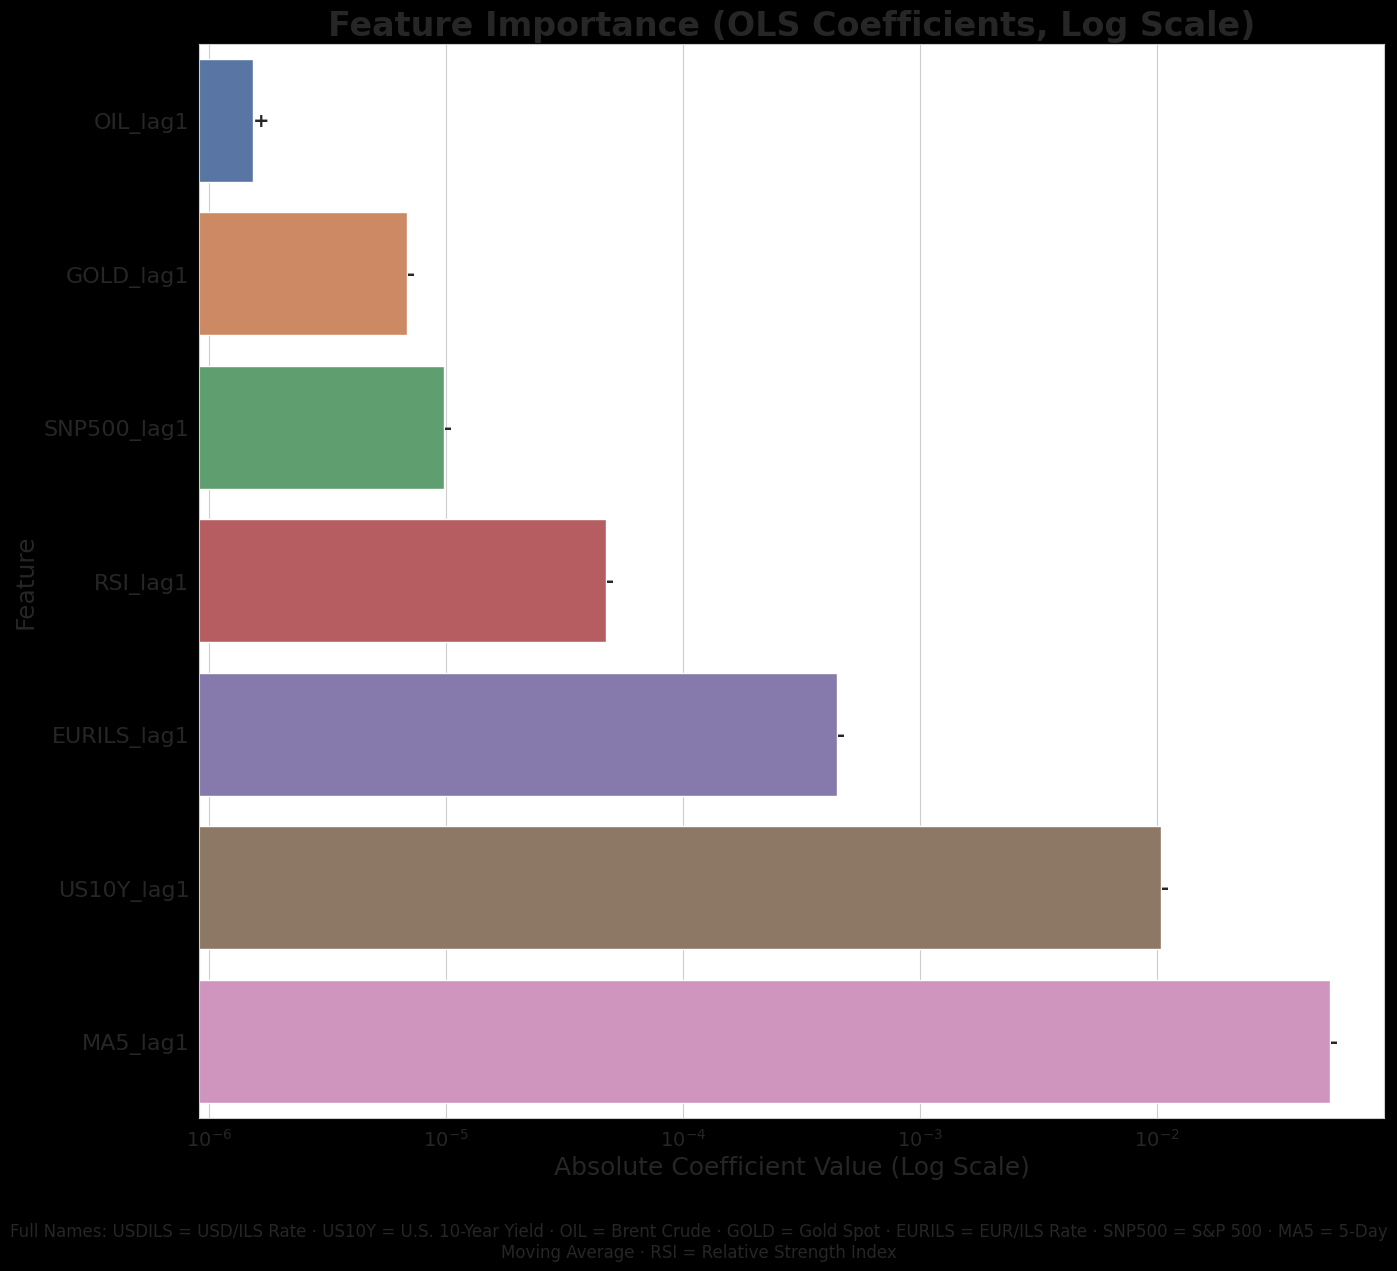

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Extract coefficients (excluding intercept)
coef = model5.params.drop("Intercept")

# Use absolute values for log scale, but keep sign separately
coef_abs = coef.abs()
coef_sign = np.sign(coef)

# Sort by absolute value
coef_sorted = coef_abs.reindex(coef_abs.sort_values(ascending=True).index)
coef_sign_sorted = coef_sign.loc[coef_sorted.index]

plt.figure(figsize=(14, 12))
sns.set_style("whitegrid")

# Horizontal bar plot using absolute values
sns.barplot(
    x=coef_sorted.values,
    y=coef_sorted.index,
    palette="deep"
)

# Apply log scale
plt.xscale("log")

# Reapply signs as text labels
for i, (val, sign) in enumerate(zip(coef_sorted.values, coef_sign_sorted.values)):
    plt.text(
        val,
        i,
        f"{'+' if sign > 0 else '-'}",
        va="center",
        ha="left",
        fontsize=14,
        weight="bold"
    )

plt.title("Feature Importance (OLS Coefficients, Log Scale)", fontsize=24, weight="bold")
plt.xlabel("Absolute Coefficient Value (Log Scale)", fontsize=18)
plt.ylabel("Feature", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=16)

# Caption with full names
plt.figtext(
    0.5, -0.05,
    "Full Names: USDILS = USD/ILS Rate · US10Y = U.S. 10-Year Yield · OIL = Brent Crude · GOLD = Gold Spot · "
    "EURILS = EUR/ILS Rate · SNP500 = S&P 500 · MA5 = 5-Day Moving Average · RSI = Relative Strength Index",
    wrap=True, ha="center", fontsize=12
)

plt.tight_layout()
plt.show()

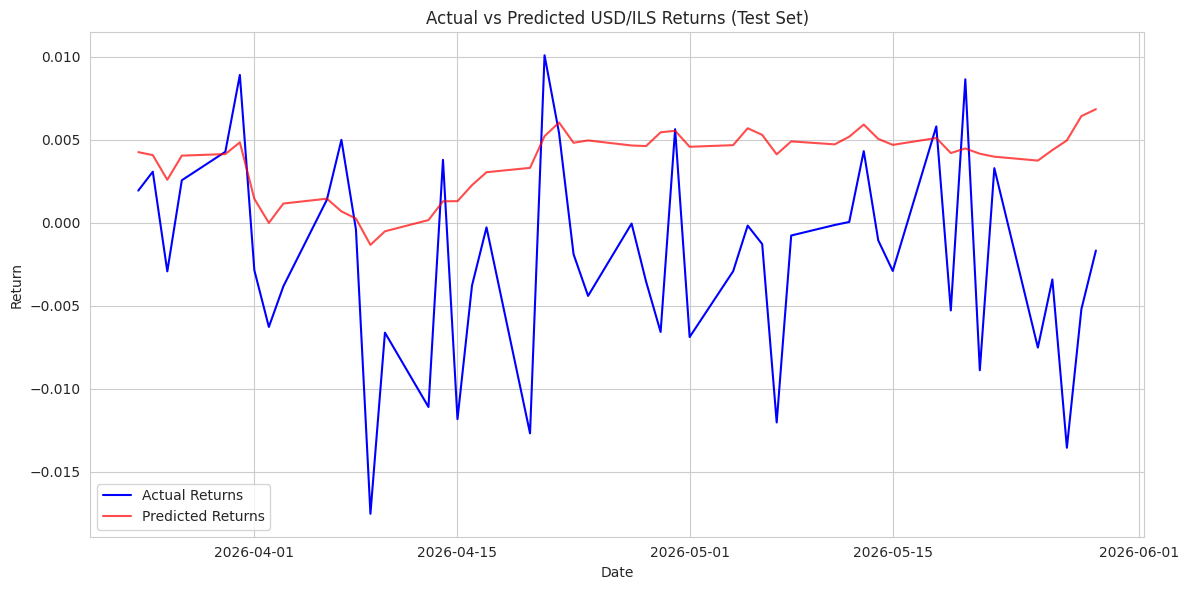

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(test['Date'], test['Return'], label='Actual Returns', color='blue')
plt.plot(test['Date'], y_pred, label='Predicted Returns', color='red', alpha=0.7)

plt.title('Actual vs Predicted USD/ILS Returns (Test Set)')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

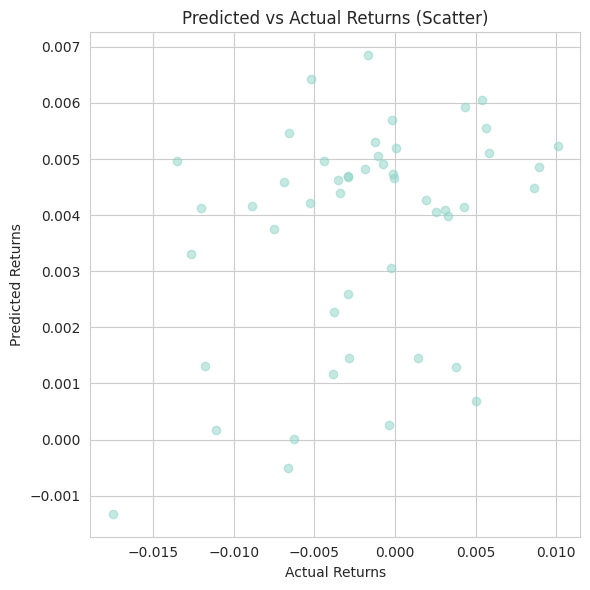

In [54]:
plt.figure(figsize=(6, 6))
plt.scatter(test['Return'], y_pred, alpha=0.5)

plt.title('Predicted vs Actual Returns (Scatter)')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.grid(True)
plt.tight_layout()
plt.show()

In [55]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# 2. Feature engineering
delta = df['USDILS'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

df['MA5'] = df['USDILS'].rolling(window=5).mean()
df['Return'] = df['USDILS'].pct_change()

In [56]:
features = ['USDILS', 'US10Y', 'OIL', 'GOLD', 'EURILS', 'SNP500', 'MA5', 'RSI']

In [57]:
features = ['US10Y', 'OIL', 'GOLD', 'EURILS', 'SNP500', 'MA5', 'RSI']
for col in features:
    df[f'{col}_lag1'] = df[col].shift(1)

In [58]:
df = df.set_index('Date')
df = df.asfreq('D')

In [59]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
'it works '

'it works '

In [60]:
df.index = pd.to_datetime(df.index)

In [61]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Hide the index/frequency warnings from statsmodels
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

# Hide the optimization convergence warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [62]:
preds = []
lower_ci = []
upper_ci = []

actuals = test['Return']
dates = test.index

for i in range(len(test)):

    # expanding training window
    rolling_train = df_model.iloc[:train_size + i]

    y_train = rolling_train['Return']
    X_train = rolling_train[[f'{col}_lag1' for col in features]]

    # exogenous variables for next prediction
    X_next = test[[f'{col}_lag1' for col in features]].iloc[i:i+1]

    # fit SARIMAX
    model = SARIMAX(
        y_train,
        exog=X_train,
        order=(1, 0, 1),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    results = model.fit(disp=False)

    # forecast
    forecast = results.get_forecast(steps=1, exog=X_next)
    pred_mean = forecast.predicted_mean.iloc[0]

    ci = forecast.conf_int().iloc[0]
    lower_ci.append(ci.iloc[0])
    upper_ci.append(ci.iloc[1])

    preds.append(pred_mean)

In [63]:
preds = []
lower_ci = []
upper_ci = []

actuals = test['Return']
dates = test.index

for i in range(len(test)):

    # expanding training window
    rolling_train = df_model.iloc[:train_size + i]

    y_train = rolling_train['Return']
    X_train = rolling_train[[f'{col}_lag1' for col in features]]

    # exogenous variables for next prediction
    X_next = test[[f'{col}_lag1' for col in features]].iloc[i:i+1]

    # fit SARIMAX
    model = SARIMAX(
        y_train,
        exog=X_train,
        order=(1, 0, 1),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    results = model.fit(disp=False)

    # forecast
    forecast = results.get_forecast(steps=1, exog=X_next)
    pred_mean = forecast.predicted_mean.iloc[0]

    ci = forecast.conf_int().iloc[0]
    lower_ci.append(ci.iloc[0])
    upper_ci.append(ci.iloc[1])

    preds.append(pred_mean)

In [64]:
results_df = pd.DataFrame({
    'Actual': actuals.values,
    'Predicted': preds,
    'Lower_CI': lower_ci,
    'Upper_CI': upper_ci
}, index=dates)

results_df.index.name = 'Date'

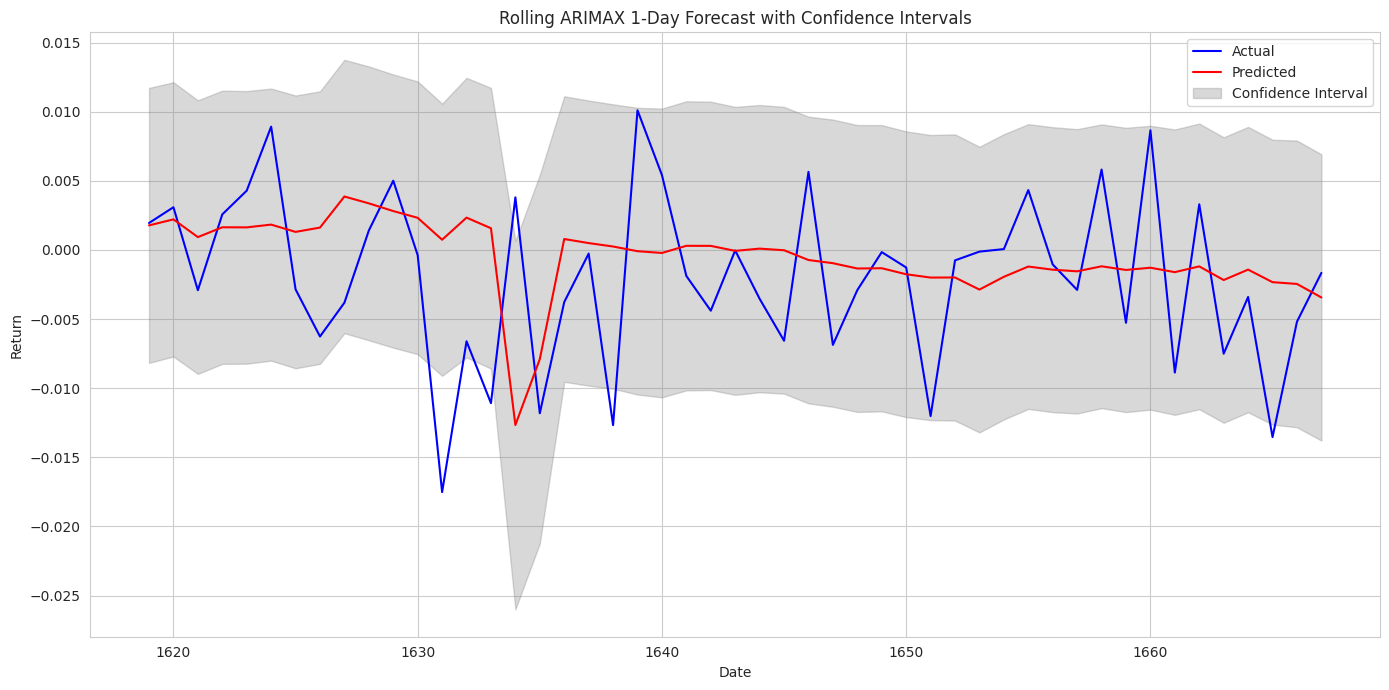

In [65]:
plt.figure(figsize=(14, 7))
plt.plot(results_df.index, results_df['Actual'], label='Actual', color='blue')
plt.plot(results_df.index, results_df['Predicted'], label='Predicted', color='red')

plt.fill_between(
    results_df.index,
    results_df['Lower_CI'],
    results_df['Upper_CI'],
    color='gray',
    alpha=0.3,
    label='Confidence Interval'
)

plt.title('Rolling ARIMAX 1‑Day Forecast with Confidence Intervals')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('the_risk_of_usd_ils.png',dpi=400)
plt.show()

In [66]:
results_df.head()

,Actual,Predicted,Lower_CI,Upper_CI
Date,,,,
1619,0.001947,0.001773,-0.008171,0.011716
1620,0.003086,0.002209,-0.007709,0.012127
1621,-0.002917,0.000926,-0.008968,0.010821
1622,0.002569,0.001636,-0.008246,0.011518
1623,0.004285,0.001630,-0.008228,0.011488


In [67]:
results_df.shape

(49, 4)

In [68]:
outliers = results_df[(results_df['Actual'] < results_df['Lower_CI']) | 
                   (results_df['Actual'] > results_df['Upper_CI'])]

outliers

,Actual,Predicted,Lower_CI,Upper_CI
Date,,,,
1631,-0.017519,0.000736,-0.009107,0.010578
1633,-0.011085,0.001567,-0.008583,0.011718
1634,0.003799,-0.012668,-0.025992,0.000656
1638,-0.012675,0.000246,-0.010039,0.010531
1665,-0.013541,-0.002333,-0.012635,0.007969


even though our model got most days in the band but it got stuck because of the war with Iran 

April 9 & April 13These fall right during the U.S.–Iran conflict escalation and Strait of Hormuz disruption, which caused:Oil price spikesRegional currency volatilityRisk‑off flowsARIMA cannot predict geopolitical shocks.🔹 April 15This is the day with the documented 6.2% USDILS crash.
No statistical model would have predicted that.
🔹 April 20
Still within the same macro shock window — markets were digesting:War uncertaintyOil supply fearsGlobal inflation concerns

m

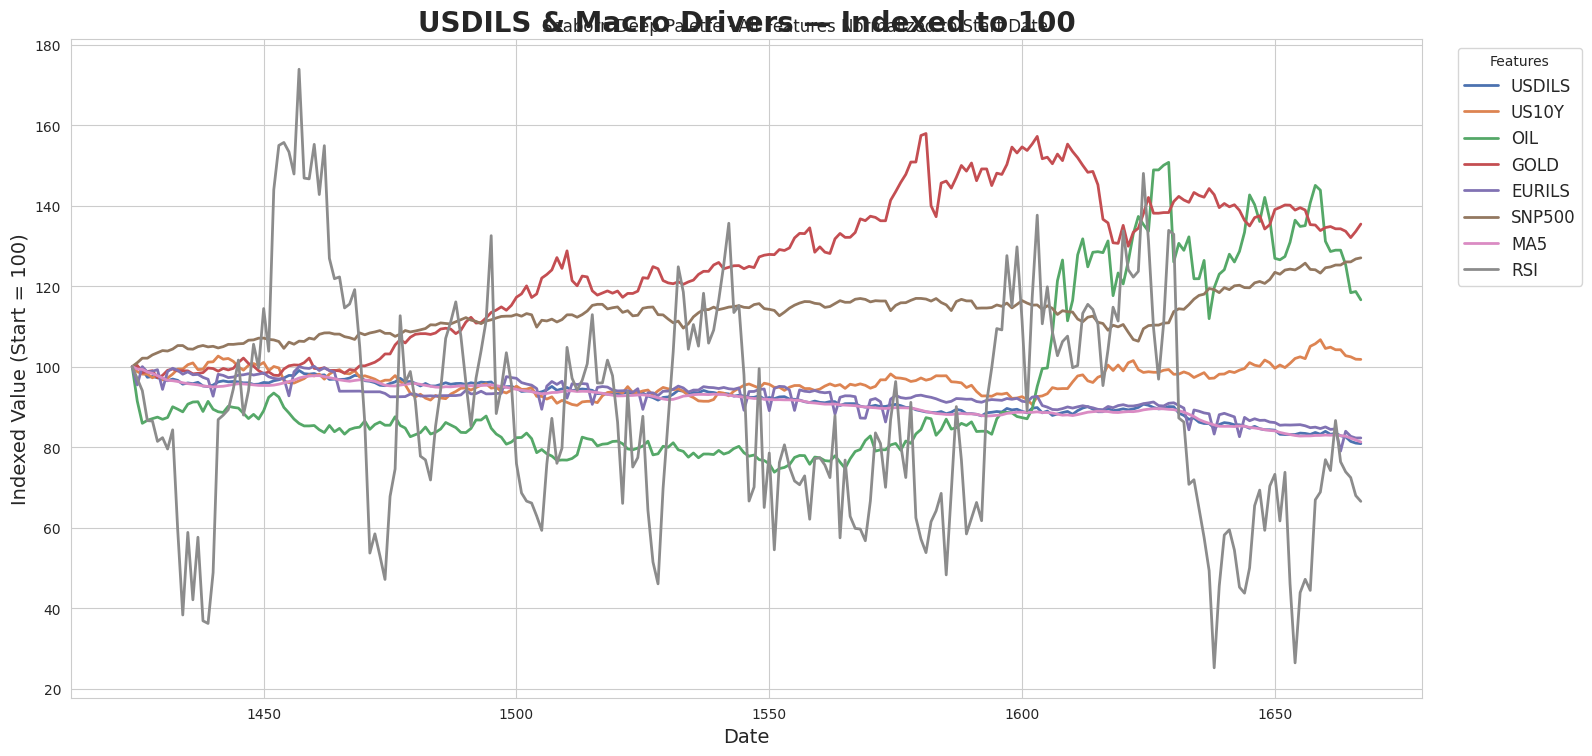

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select features
features = ['USDILS', 'US10Y', 'OIL', 'GOLD', 'EURILS', 'SNP500', 'MA5', 'RSI']

# Create indexed dataframe (each series starts at 100)
indexed_df = df_model[features].copy()
indexed_df = indexed_df / indexed_df.iloc[0] * 100

# Plot styling
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")
palette = sns.color_palette("deep", len(features))

for i, col in enumerate(features):
    plt.plot(indexed_df.index, indexed_df[col], label=col, linewidth=2, color=palette[i])

# Bloomberg-style title
plt.title("USDILS & Macro Drivers — Indexed to 100", fontsize=20, weight='bold')
plt.suptitle("Seaborn Deep Palette · All Features Normalized to Start Date", fontsize=12, y=0.93)

# Legend outside the plot
plt.legend(title="Features", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Indexed Value (Start = 100)", fontsize=14)
plt.tight_layout()
plt.savefig('USDILS_macro_drives.png',dpi=400)
plt.show()

In [70]:
df1=df.copy()

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# Load your data
cols = ["US10Y","USDILS", "OIL", "GOLD", "EURILS", "SNP500", "NASDAQ100", "Fear_Greed"]
df = df_new[cols].copy()

In [72]:
import numpy as np
import pandas as pd

stationary_df = pd.DataFrame()

for col in df.columns:
    stationary_df[col] = np.log(df[col]).diff()

stationary_df = stationary_df.dropna()

In [73]:
def make_stationary(series):
    result = adfuller(series.dropna())
    if result[1] > 0.05:
        return series.diff().dropna(), True
    return series.dropna(), False

stationary_df = pd.DataFrame()
diff_info = {}

for col in df.columns:
    stationary_df[col], diffed = make_stationary(df[col])
    diff_info[col] = diffed

print("Differenced columns:", diff_info)

# Align after differencing
stationary_df = stationary_df.dropna()

Differenced columns:
{
    'US10Y': True,
    'USDILS': True,
    'OIL': True,
    'GOLD': True,
    'EURILS': True,
    'SNP500': True,
    'NASDAQ100': True,
    'Fear_Greed': True
}

In [74]:
stationary_df.head()

,US10Y,USDILS,OIL,GOLD,EURILS,SNP500,NASDAQ100,Fear_Greed
1411,-0.002,0.00936,0.889999,-20.400146,0.0309,34.430176,170.830078,-7.857143
1412,-0.095,-0.00796,-0.560001,23.300049,-0.0215,0.439941,59.339844,0.314286
1413,0.029,-0.03538,0.520000,-22.800049,-0.0230,-31.510254,-174.490234,3.085714
1414,0.116,0.00732,1.210003,-28.000000,0.0157,61.060059,214.359375,3.800000
1415,-0.028,0.01012,0.709999,9.400146,-0.1987,5.520020,36.080078,1.657143


In [75]:
model = VAR(stationary_df)

lag_selection = model.select_order(maxlags=12)
optimal_lag = lag_selection.aic

print("Optimal lag:", optimal_lag)

var_results = model.fit(optimal_lag)

Optimal lag: 1

In [76]:
res = var_results.resid["USDILS"]

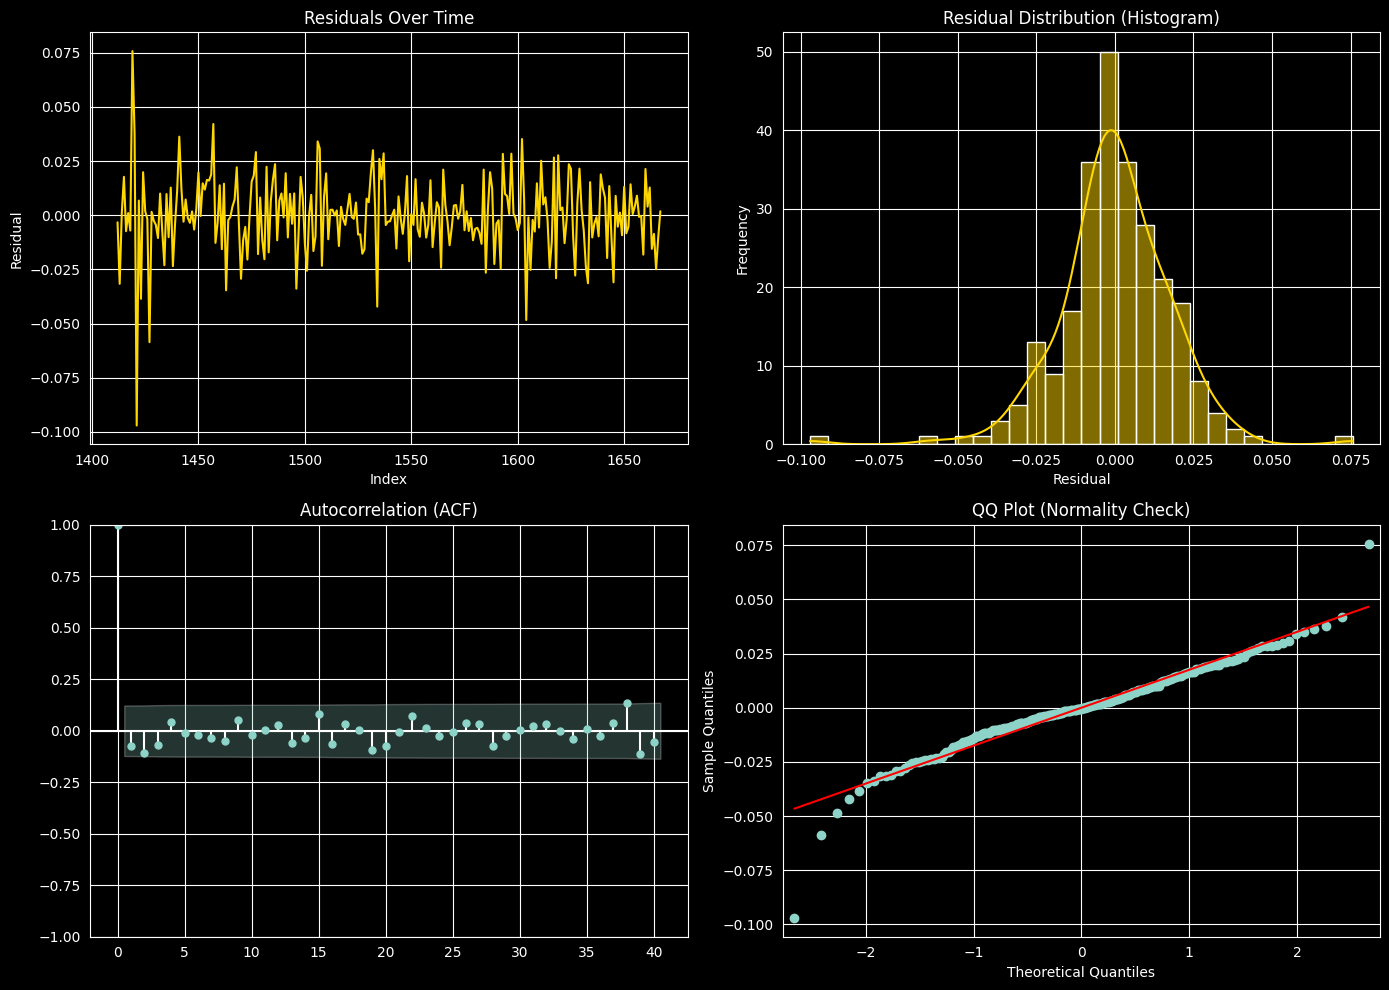

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

plt.style.use("dark_background")  # optional, looks great

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals Over Time
axes[0, 0].plot(res, color="gold")
axes[0, 0].set_title("Residuals Over Time", color="white")
axes[0, 0].set_xlabel("Index", color="white")
axes[0, 0].set_ylabel("Residual", color="white")

# 2. Histogram
sns.histplot(res, bins=30, kde=True, color="gold", ax=axes[0, 1])
axes[0, 1].set_title("Residual Distribution (Histogram)", color="white")
axes[0, 1].set_xlabel("Residual", color="white")
axes[0, 1].set_ylabel("Frequency", color="white")

# 3. ACF Plot
plot_acf(res, ax=axes[1, 0], lags=40)
axes[1, 0].set_title("Autocorrelation (ACF)", color="white")

# 4. QQ Plot
sm.qqplot(res, line="s", ax=axes[1, 1])
axes[1, 1].set_title("QQ Plot (Normality Check)", color="white")

plt.tight_layout()
plt.savefig('var_plot_Usdils.png',dpi=400)
plt.show()

1 Top-Left: Residuals Over Time
​This is a standard line plot tracking the model's errors across the index (timeline).
​What you want to see: The line should fluctuate randomly around a mean of zero, with a relatively constant variance (height of the spikes) across the entire timeline.
​Interpretation: Your plot looks quite healthy. It looks like random noise centered tightly around 0.00. There are no obvious massive shifts in volatility (heteroskedasticity) or long-term structural trends, meaning the model captured the core movement over time well.


this is the 1 for var for USDILS 
​When analyzing a time series model, we look at the residuals (the errors, or the difference between actual values and predicted values). Ideally, we want these residuals to behave like White Noise: random, normally distributed, and uncorrelated.
​Here is a breakdown of what each plot means and how to interpret them:
​1. Top-Left: Residuals Over Time
​This is a standard line plot tracking the model's errors across the index (timeline).
​What you want to see: The line should fluctuate randomly around a mean of zero, with a relatively constant variance (height of the spikes) across the entire timeline.
​Interpretation: Your plot looks quite healthy. It looks like random noise centered tightly around 0.00. There are no obvious massive shifts in volatility (heteroskedasticity) or long-term structural trends, meaning the model captured the core movement over time well.
​2. Top-Right: Residual Distribution (Histogram)
​This plot shows the frequency distribution of the error values, overlaid with a KDE (Kernel Density Estimate) smooth curve.
​What you want to see: A bell-shaped curve centered at 0, representing a standard Normal Distribution.
​Interpretation: The histogram looks excellent. It is highly symmetric, peaks right at 0, and tapers off nicely on both sides. This indicates that the model's errors are normally distributed, which satisfies a key assumption for making valid statistical inferences (like confidence intervals).
​3. Bottom-Left: Autocorrelation Function (ACF) Plot
​The ACF plot measures how correlated a residual is with past versions of itself (at different "lags").
​What you want to see: Aside from lag 0 (which is always 1.0 because a value is perfectly correlated with itself), all the other vertical bars should stay inside the shaded blue region (the confidence interval).
​Interpretation: Looking closely, almost all the spikes fall well within the shaded boundary. This means there is no significant autocorrelation left in the residuals. The model successfully extracted all the predictable time-dependent patterns from the data, leaving behind pure, unpredictable noise.
​4. Bottom-Right: QQ Plot (Normality Check)
​The Quantile-Quantile (QQ) plot compares the distribution of your residuals against a theoretical perfect normal distribution (the red diagonal line).
​What you want to see: The blue dots should align closely along the straight red line.
​Interpretation: For the vast majority of the data, the points sit perfectly on the red line. There is a slight deviation at the very left "tail" (bottom left corner), where a couple of dots fall below the line. This indicates a minor amount of "heavy tails" or slight outliers in the negative direction, but it is incredibly minor. Overall, it strongly confirms the normality observed in the histogram.
​Summary Verdict
​Excellent Model Fit. These diagnostics are about as close to textbook "White Noise" as you will get with real-world financial data. Your model has successfully captured the underlying structure of the USD/ILS trend, and the remaining errors are random, normally distributed, and uncorrelated.

In [78]:
res = var_results.resid["EURILS"]

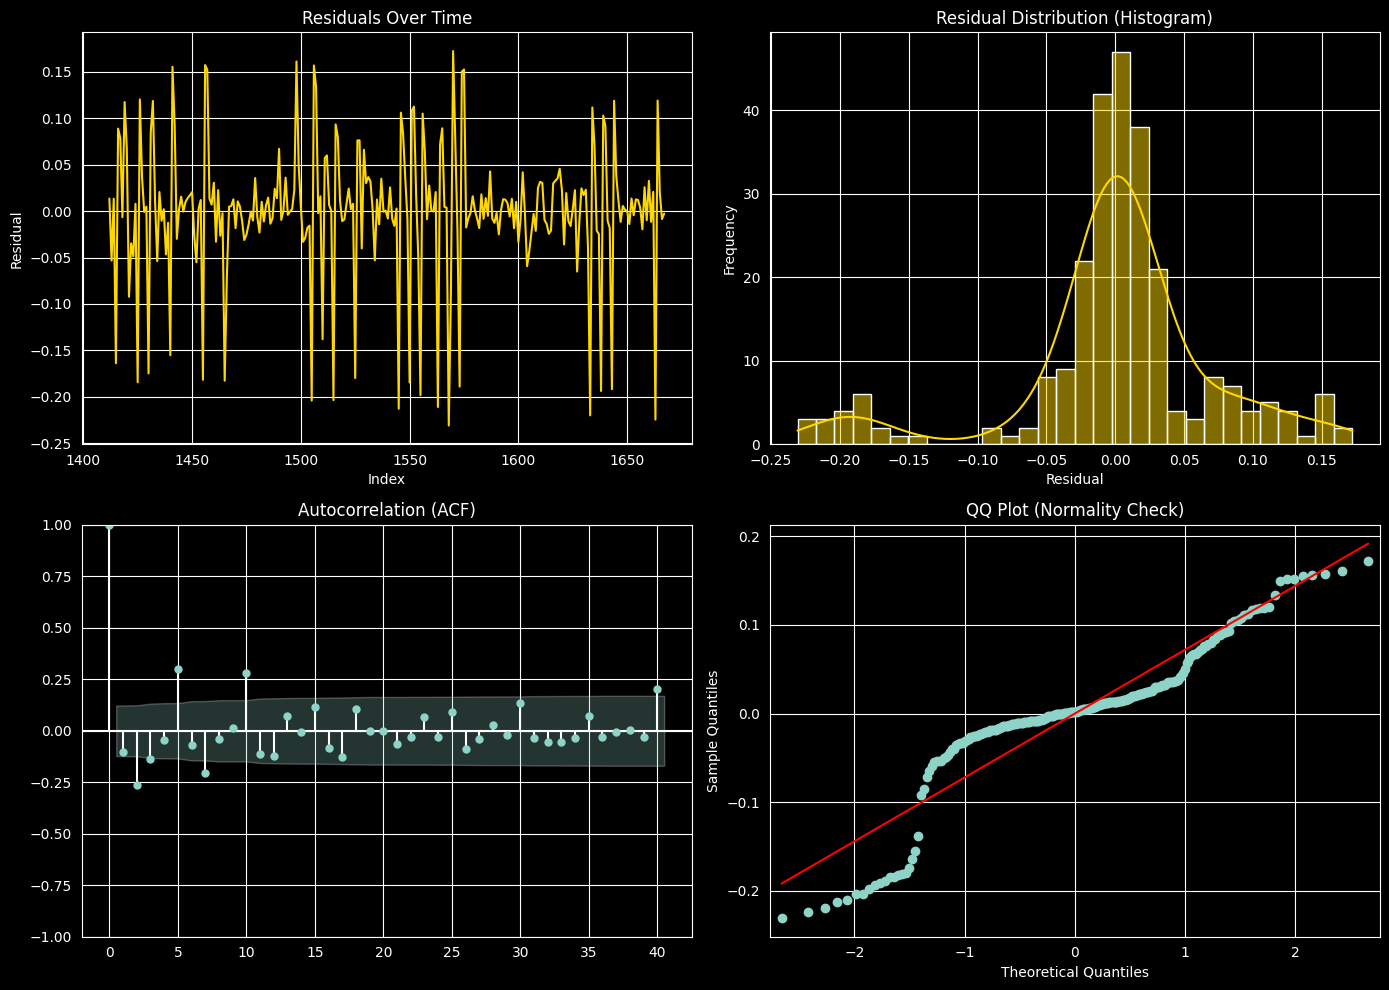

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

plt.style.use("dark_background")  # optional, looks great

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals Over Time
axes[0, 0].plot(res, color="gold")
axes[0, 0].set_title("Residuals Over Time", color="white")
axes[0, 0].set_xlabel("Index", color="white")
axes[0, 0].set_ylabel("Residual", color="white")

# 2. Histogram
sns.histplot(res, bins=30, kde=True, color="gold", ax=axes[0, 1])
axes[0, 1].set_title("Residual Distribution (Histogram)", color="white")
axes[0, 1].set_xlabel("Residual", color="white")
axes[0, 1].set_ylabel("Frequency", color="white")

# 3. ACF Plot
plot_acf(res, ax=axes[1, 0], lags=40)
axes[1, 0].set_title("Autocorrelation (ACF)", color="white")

# 4. QQ Plot
sm.qqplot(res, line="s", ax=axes[1, 1])
axes[1, 1].set_title("QQ Plot (Normality Check)", color="white")
plt.savefig('var_plot_eurils.png',dpi=400)
plt.tight_layout()
plt.show()


​You are observing a classic case of cross-currency discrepancy in a joint model. Even though the framework handles the USD/ILS dynamics beautifully, it struggles to adapt perfectly to the structural differences or specific market shocks present in the EUR/ILS data.
​When you write this up, here is a polished, professional way to articulate these findings in Markdown:
​Model Performance & Residual Diagnostics Discussion
​While the model demonstrates an excellent fit for the USD/ILS exchange rate—with residuals closely mimicking ideal white noise—the diagnostics reveal that it does not capture the dynamics of EUR/ILS with the same degree of precision.
​The primary areas of divergence include:
​Non-Normality and Heavy Tails: The EUR/ILS QQ plot displays a sharp downward departure from the reference line in the lower-left quadrant. This signifies a heavily skewed left tail, indicating that the model fails to account for sudden, extreme downside shocks specific to the Euro-Shekel pair.
​Volatility Clustering: The residual time series for EUR/ILS shows distinct periods of shifting variance (heteroskedasticity) rather than a constant band of random noise.
​Implications: While the system remains highly predictive for the Dollar-based pair, the underlying OLS assumptions are partially violated for the Euro-based equations. Future iterations may require a VAR-GARCH framework to dynamically model this localized volatility and fat-tailed risk.
​Does this capture the exact narrative you want to present, or should we refine the wording to match a specific section of your analysis?

In [80]:
var_results.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 05, Sep, 2026
Time:                     20:28:18
--------------------------------------------------------------------
No. of Equations:         8.00000    BIC:                    10.6596
Nobs:                     256.000    HQIC:                   10.0635
Log likelihood:          -4070.79    FPE:                    15721.0
AIC:                      9.66252    Det(Omega_mle):         11924.3
--------------------------------------------------------------------
Results for equation US10Y
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.000505         0.002684            0.188           0.851
L1.US10Y             -0.087728         0.070088           -1.252           0.211
L1.USDILS            -0.056014         0.135100           -0

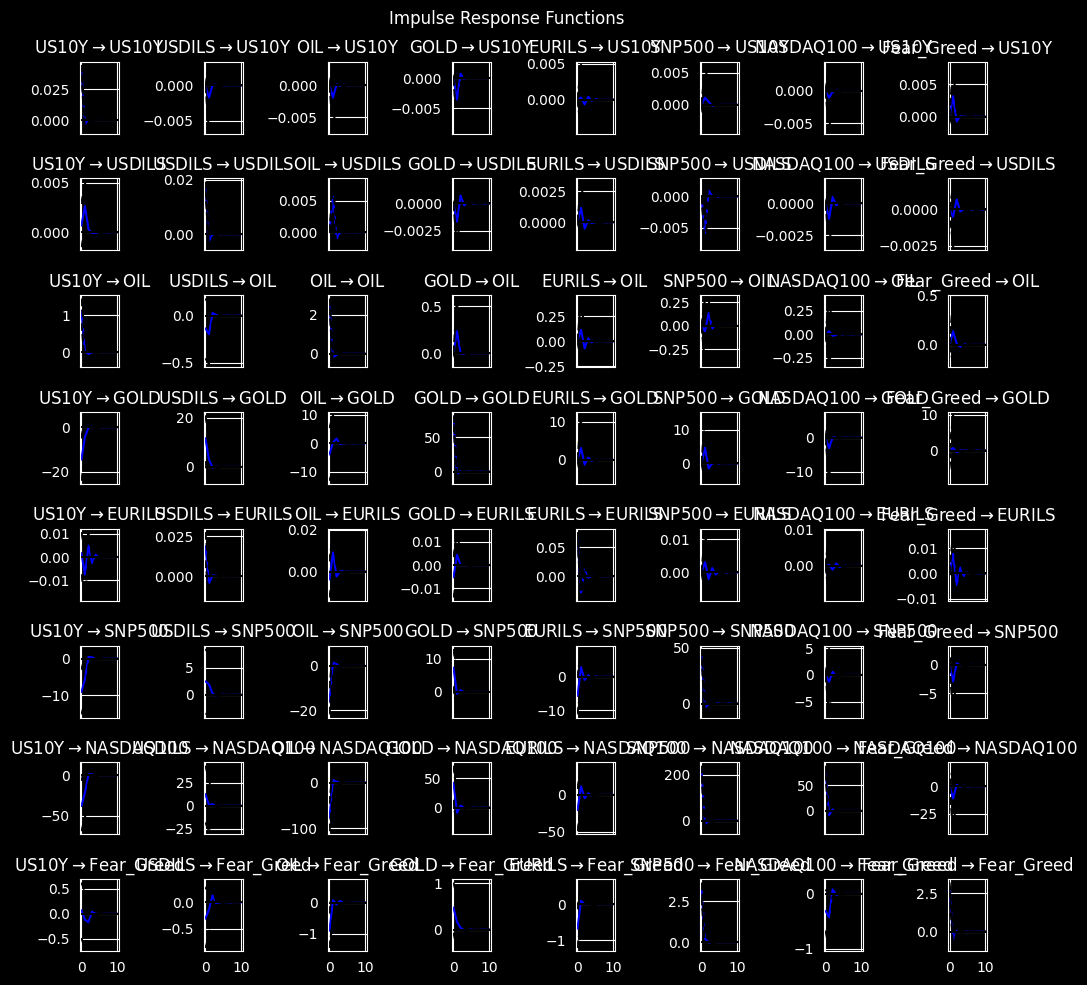

In [81]:
irf = var_results.irf(10)
irf.plot(orth=True)
plt.suptitle("Impulse Response Functions", fontsize=12)
plt.tight_layout()
plt.savefig("impulse_response.png",dpi=400)
plt.show()

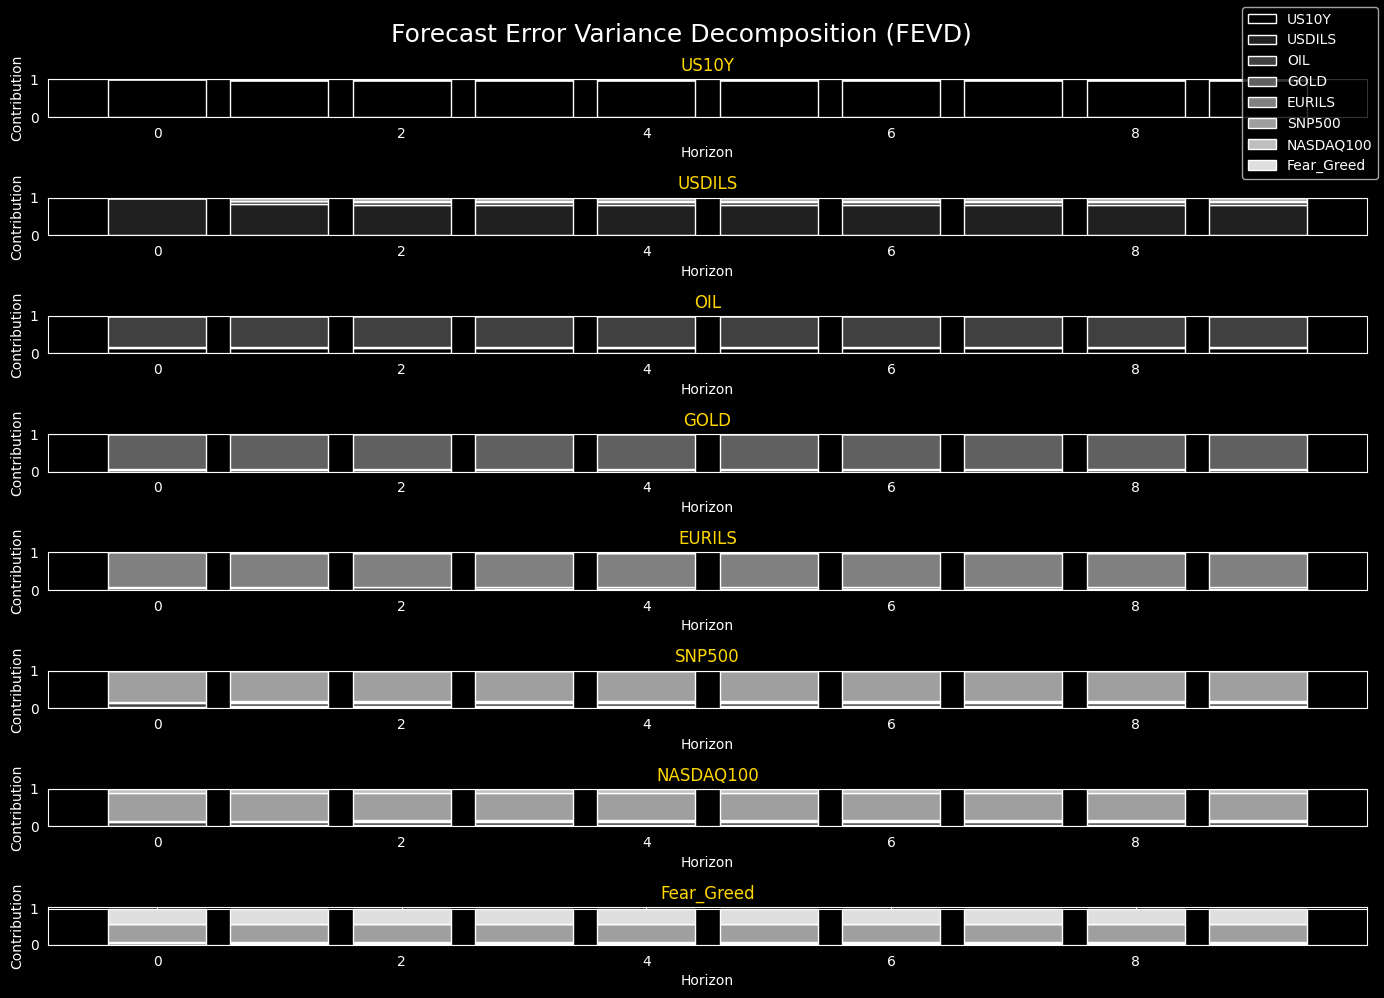

In [82]:
plt.style.use("dark_background")

fevd = var_results.fevd(10)
fig = fevd.plot(figsize=(14, 10))

plt.suptitle("Forecast Error Variance Decomposition (FEVD)", color="white", fontsize=18)

# Style axes
for ax in fig.axes:
    ax.set_xlabel("Horizon", color="white")
    ax.set_ylabel("Contribution", color="white")
    ax.title.set_color("gold")
    ax.tick_params(colors="white")

# Style legend safely
for ax in fig.axes:
    leg = ax.get_legend()
    if leg is not None:
        for text in leg.get_texts():
            text.set_color("white")

plt.tight_layout()
plt.savefig('forecast_error_var.png',dpi=400)
plt.show()

In [83]:
forecast_input = stationary_df.values[-optimal_lag:]
forecast_values = var_results.forecast(forecast_input, steps=12)

forecast_df = pd.DataFrame(
    forecast_values,
    columns=[c + "_forecast" for c in stationary_df.columns]
)

forecast_df

,US10Y_forecast,USDILS_forecast,OIL_forecast,GOLD_forecast,EURILS_forecast,SNP500_forecast,NASDAQ100_forecast,Fear_Greed_forecast
0,-0.002893,-0.006678,0.354490,0.282271,-0.011199,6.655190,30.522637,0.231673
1,0.000650,-0.001955,0.102965,4.699200,0.001563,6.085623,34.863609,0.065895
2,-0.000017,-0.002830,0.099012,4.901325,-0.004326,6.262493,33.458860,-0.015983
3,-0.000059,-0.002744,0.094755,4.584990,-0.002299,6.240337,33.683328,0.018959
4,0.000016,-0.002753,0.097948,4.727071,-0.002988,6.272914,33.820229,0.011125
5,-0.000017,-0.002755,0.096869,4.673322,-0.002751,6.248901,33.708526,0.012904
6,-0.000005,-0.002752,0.097292,4.690938,-0.002833,6.258889,33.756174,0.012317
7,-0.000009,-0.002753,0.097102,4.685318,-0.002804,6.255423,33.738830,0.012504
8,-0.000007,-0.002753,0.097177,4.687216,-0.002814,6.256664,33.745153,0.012452
9,-0.000008,-0.002753,0.097150,4.686547,-0.002810,6.256205,33.742841,0.012468


In [84]:
model = VAR(stationary_df)
lag_selection = model.select_order(maxlags=12)
lag_selection.summary()

,AIC,BIC,FPE,HQIC
0,9.742,9.857*,1.702e+04,9.788*
1,9.485*,10.51,1.316e+04*,9.899
2,9.608,11.55,1.492e+04,10.39
3,9.780,12.64,1.778e+04,10.93
4,9.888,13.66,1.996e+04,11.41
5,10.10,14.79,2.502e+04,11.99
6,10.14,15.74,2.648e+04,12.40
7,10.32,16.84,3.259e+04,12.95
8,10.39,17.82,3.597e+04,13.38
9,10.54,18.89,4.391e+04,13.90


In [85]:
forecast_df

,US10Y_forecast,USDILS_forecast,OIL_forecast,GOLD_forecast,EURILS_forecast,SNP500_forecast,NASDAQ100_forecast,Fear_Greed_forecast
0,-0.002893,-0.006678,0.354490,0.282271,-0.011199,6.655190,30.522637,0.231673
1,0.000650,-0.001955,0.102965,4.699200,0.001563,6.085623,34.863609,0.065895
2,-0.000017,-0.002830,0.099012,4.901325,-0.004326,6.262493,33.458860,-0.015983
3,-0.000059,-0.002744,0.094755,4.584990,-0.002299,6.240337,33.683328,0.018959
4,0.000016,-0.002753,0.097948,4.727071,-0.002988,6.272914,33.820229,0.011125
5,-0.000017,-0.002755,0.096869,4.673322,-0.002751,6.248901,33.708526,0.012904
6,-0.000005,-0.002752,0.097292,4.690938,-0.002833,6.258889,33.756174,0.012317
7,-0.000009,-0.002753,0.097102,4.685318,-0.002804,6.255423,33.738830,0.012504
8,-0.000007,-0.002753,0.097177,4.687216,-0.002814,6.256664,33.745153,0.012452
9,-0.000008,-0.002753,0.097150,4.686547,-0.002810,6.256205,33.742841,0.012468


In [86]:
df_new.columns

Index(['Date', 'USDILS', 'US10Y', 'OIL', 'GOLD', 'EURILS', 'SNP500',
       'NASDAQ100', 'Fear_Greed'],
      dtype='object')

In [87]:
df_new["Return"] = df_new["USDILS"].diff()
df_new['Return'].describe()

count    257.000000
mean      -0.002708
std        0.019830
min       -0.113090
25%       -0.012910
50%       -0.002200
75%        0.010120
max        0.071270
Name: Return, dtype: float64

In [88]:
cols = ["Return", "US10Y", "OIL", "GOLD", "EURILS", "SNP500", "NASDAQ100", "Fear_Greed"]
data = df_new[cols].dropna().copy()

In [89]:
data.columns

Index(['Return', 'US10Y', 'OIL', 'GOLD', 'EURILS', 'SNP500', 'NASDAQ100',
       'Fear_Greed'],
      dtype='object')

In [90]:
from statsmodels.tsa.api import VAR

model = VAR(data)
lag_sel = model.select_order(maxlags=10)
p = lag_sel.aic
print("Lag used:", p)

var_res = model.fit(p)

Lag used: 2

In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257 entries, 1411 to 1667
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Return      257 non-null    float64
 1   US10Y       257 non-null    float64
 2   OIL         257 non-null    float64
 3   GOLD        257 non-null    float64
 4   EURILS      257 non-null    float64
 5   SNP500      257 non-null    float64
 6   NASDAQ100   257 non-null    float64
 7   Fear_Greed  257 non-null    float64
dtypes: float64(8)
memory usage: 18.1 KB


In [92]:
values = data.values

In [93]:
var_cols = ["Return", "US10Y", "OIL", "GOLD", "EURILS", "SNP500", "NASDAQ100", "Fear_Greed"]
values = data[var_cols].values

In [94]:
var_cols = ["Return", "US10Y", "OIL", "GOLD", "EURILS", "SNP500", "NASDAQ100", "Fear_Greed"]

data["Return_forecast"] = np.nan
values = data[var_cols].values  # ONLY the 8 variables used in VAR

for t in range(p, len(data)):
    window = values[t-p:t]
    fc = var_res.forecast(window, steps=1)
    data.iloc[t, data.columns.get_loc("Return_forecast")] = fc[0][0]

In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257 entries, 1411 to 1667
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Return           257 non-null    float64
 1   US10Y            257 non-null    float64
 2   OIL              257 non-null    float64
 3   GOLD             257 non-null    float64
 4   EURILS           257 non-null    float64
 5   SNP500           257 non-null    float64
 6   NASDAQ100        257 non-null    float64
 7   Fear_Greed       257 non-null    float64
 8   Return_forecast  255 non-null    float64
dtypes: float64(9)
memory usage: 20.1 KB


In [96]:
data.tail()

,Return,US10Y,OIL,GOLD,EURILS,SNP500,NASDAQ100,Fear_Greed,Return_forecast
1663,-0.02186,4.558,96.599998,4521.000000,3.155900,7473.470215,29481.640625,58.971429,-0.008541
1664,-0.00984,4.493,93.889999,4500.399902,3.353110,7519.120117,30001.320312,60.914286,0.001696
1665,-0.03900,4.481,88.680000,4447.500000,3.302783,7520.359863,29973.570312,60.600000,-0.010037
1666,-0.01476,4.455,88.900002,4499.299805,3.285892,7563.629883,30223.890625,60.085714,-0.002965
1667,-0.00470,4.453,87.360001,4560.500000,3.286580,7580.060059,30333.179688,59.171429,-0.002627


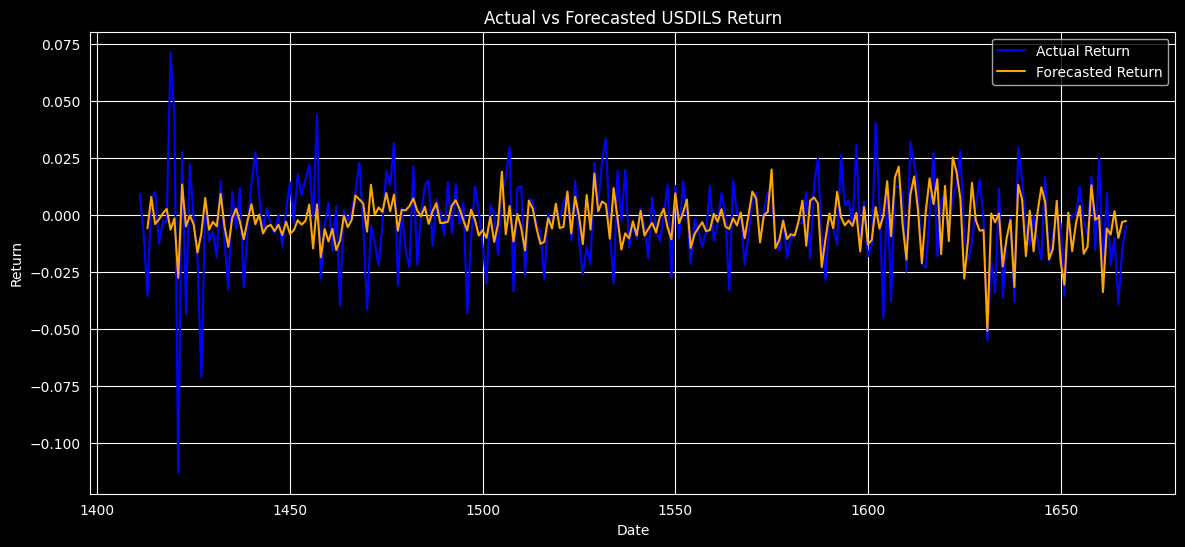

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(data.index, data["Return"], label="Actual Return", color="blue", linewidth=1.5)
plt.plot(data.index, data["Return_forecast"], label="Forecasted Return", color="orange", linewidth=1.5)

plt.title("Actual vs Forecasted USDILS Return")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.savefig('forecplt_actual_var.png',dpi=400)
plt.show()

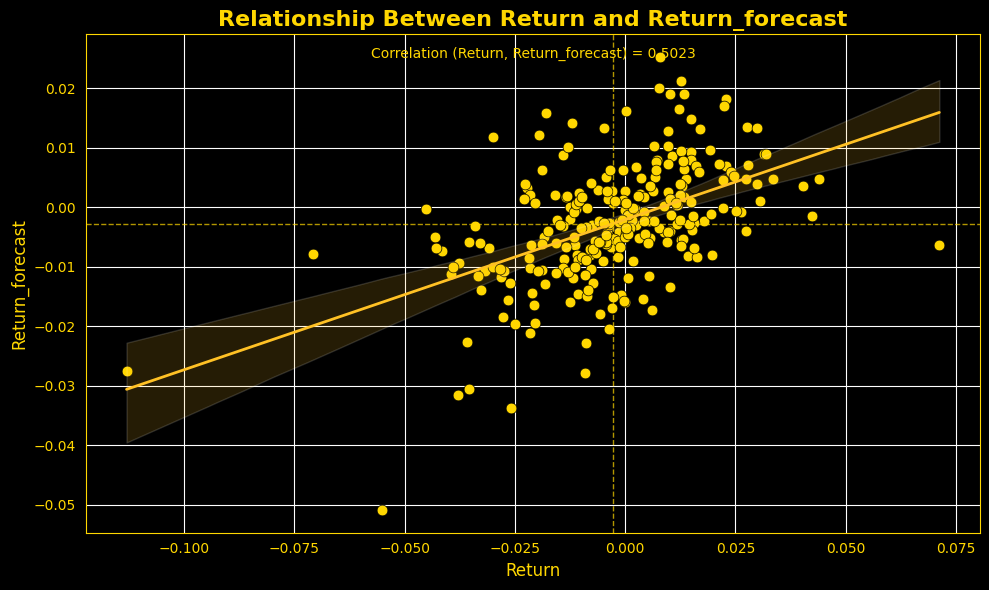

'Relationship_Between_Return_and_Return_forecast.png'

In [98]:
scatter_with_corr(data,'Return','Return_forecast')

In [99]:
data.head()

,Return,US10Y,OIL,GOLD,EURILS,SNP500,NASDAQ100,Fear_Greed,Return_forecast
1411,0.00936,4.460,63.410000,3350.199951,4.0224,5970.370117,21662.580078,54.571429,NaN
1412,-0.00796,4.365,62.849998,3373.500000,4.0009,5970.810059,21721.919922,54.885714,NaN
1413,-0.03538,4.394,63.369999,3350.699951,3.9779,5939.299805,21547.429688,57.971429,-0.005781
1414,0.00732,4.510,64.580002,3322.699951,3.9936,6000.359863,21761.789062,61.771429,0.007945
1415,0.01012,4.482,65.290001,3332.100098,3.7949,6005.879883,21797.869141,63.428571,-0.003924


In [100]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Actual vs forecasted
actual = data["Return"].dropna()
forecast = data["Return_forecast"].dropna()

# Align indices (important!)
actual, forecast = actual.align(forecast, join="inner")

# Compute metrics
rmse = np.sqrt(mean_squared_error(actual, forecast))
mae = mean_absolute_error(actual, forecast)
mape = np.mean(np.abs((actual - forecast) / actual)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

RMSE: 0.017164886103702714

MAE: 0.012436037263295134

MAPE: 271.1917656847282

In [101]:
nrmse = rmse / actual.std()
print("Normalized RMSE:", nrmse)

Normalized RMSE: 0.862978116293266

In [102]:
# Actual and forecasted returns
actual = data["Return"].dropna()
forecast = data["Return_forecast"].dropna()

# Align indices
actual, forecast = actual.align(forecast, join="inner")

# Convert to direction: +1 for up, -1 for down
actual_dir = np.sign(actual)
forecast_dir = np.sign(forecast)

# Directional accuracy
direction_accuracy = (actual_dir == forecast_dir).mean() * 100

print("Directional Accuracy (%):", direction_accuracy)

Directional Accuracy (%): 67.84313725490196

In [103]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# Actual and forecasted returns
actual = data["Return"].dropna()
forecast = data["Return_forecast"].dropna()

# Align indices
actual, forecast = actual.align(forecast, join="inner")

# Convert to direction: +1 = up, -1 = down
actual_dir = np.sign(actual)
forecast_dir = np.sign(forecast)

# Build confusion matrix
labels = [-1, 1]  # down, up
cm = confusion_matrix(actual_dir, forecast_dir, labels=labels)

# Put into a readable DataFrame
cm_df = pd.DataFrame(
    cm,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

cm_df

,Predicted Down,Predicted Up
Actual Down,109,32
Actual Up,50,64


In [104]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# Actual and forecasted returns
actual = data["Return"].dropna()
forecast = data["Return_forecast"].dropna()

# Align indices
actual, forecast = actual.align(forecast, join="inner")

# Convert to direction: +1 = up, -1 = down
actual_dir = np.sign(actual)
forecast_dir = np.sign(forecast)

# Confusion matrix
labels = [-1, 1]  # Down, Up
cm = confusion_matrix(actual_dir, forecast_dir, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)

print("Confusion Matrix:")
print(cm_df)

# Directional accuracy
direction_accuracy = (actual_dir == forecast_dir).mean() * 100
print("\nDirectional Accuracy (%):", direction_accuracy)

# Precision, recall, F1 for predicting UP
precision_up = precision_score(actual_dir, forecast_dir, pos_label=1)
recall_up = recall_score(actual_dir, forecast_dir, pos_label=1)
f1_up = f1_score(actual_dir, forecast_dir, pos_label=1)

print("\nPrecision (Up):", precision_up)
print("Recall (Up):", recall_up)
print("F1 Score (Up):", f1_up)

Confusion Matrix:

Predicted Down  Predicted Up
Actual Down             109            32
Actual Up                50            64

Directional Accuracy (%): 67.84313725490196

Precision (Up): 0.6666666666666666

Recall (Up): 0.5614035087719298

F1 Score (Up): 0.6095238095238096

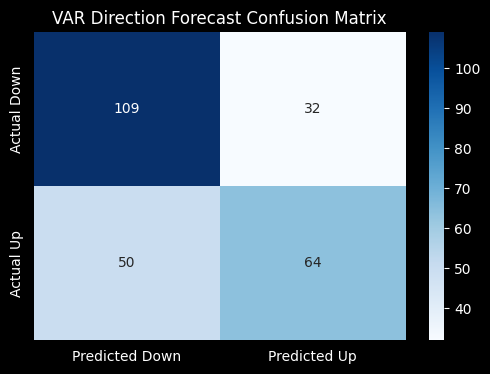

In [105]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("VAR Direction Forecast Confusion Matrix")
plt.savefig('var_diretion.png',dpi=400)
plt.show()

In [106]:
df1.head()

,USDILS,US10Y,OIL,GOLD,EURILS,SNP500,NASDAQ100,Fear_Greed,RSI,MA5,Return,US10Y_lag1,OIL_lag1,GOLD_lag1,EURILS_lag1,SNP500_lag1,MA5_lag1,RSI_lag1
Date,,,,,,,,,,,,,,,,,,
2025-06-02,3.51754,4.462,62.520000,3370.600098,3.9915,5935.939941,21491.750000,62.428571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-03,3.52690,4.460,63.410000,3350.199951,4.0224,5970.370117,21662.580078,54.571429,NaN,NaN,0.002661,4.462,62.520000,3370.600098,3.9915,5935.939941,NaN,NaN
2025-06-04,3.51894,4.365,62.849998,3373.500000,4.0009,5970.810059,21721.919922,54.885714,NaN,NaN,-0.002257,4.460,63.410000,3350.199951,4.0224,5970.370117,NaN,NaN
2025-06-05,3.48356,4.394,63.369999,3350.699951,3.9779,5939.299805,21547.429688,57.971429,NaN,NaN,-0.010054,4.365,62.849998,3373.500000,4.0009,5970.810059,NaN,NaN
2025-06-06,3.49088,4.510,64.580002,3322.699951,3.9936,6000.359863,21761.789062,61.771429,NaN,3.507564,0.002101,4.394,63.369999,3350.699951,3.9779,5939.299805,NaN,NaN


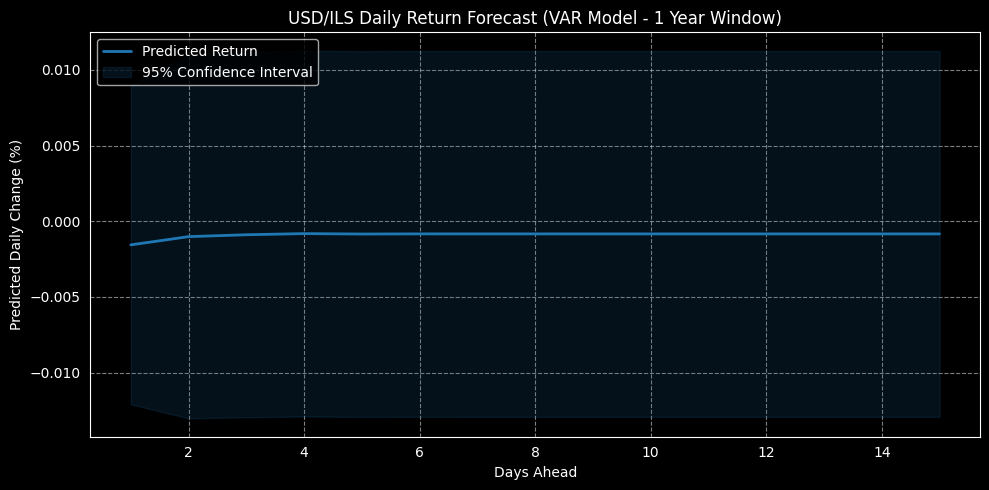

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# 1. Load data and sort by date
df = pd.read_csv(path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# 2. Select only your specified features
features = ['USDILS', 'SNP500', 'US10Y']
df_selected = df[['Date'] + features].copy()

# 3. Transform to daily returns (percentage change) to make data stationary
df_returns = df_selected.copy()
for col in features:
    df_returns[col] = df_selected[col].pct_change()
df_returns = df_returns.dropna().reset_index(drop=True)

# 4. Use only the last 1 year of data (approx. 252 trading days)
data_1y = df_returns[features].tail(252).copy()

# 5. Fit the VAR model (using 2 days of lags)
model = VAR(data_1y)
results = model.fit(2)

# 6. Generate the forecast and confidence intervals
lag_order = results.k_ar
forecast_input = data_1y.values[-lag_order:]
steps = 15  # Forecast next 15 trading days

# alpha=0.05 gives a 95% confidence level
mid_forecast, lower_bound, upper_bound = results.forecast_interval(forecast_input, steps=steps, alpha=0.05)

# 7. Extract the specific forecast arrays for USDILS (index 0)
usdils_idx = features.index('USDILS')
usdils_mid = mid_forecast[:, usdils_idx]
usdils_low = lower_bound[:, usdils_idx]
usdils_high = upper_bound[:, usdils_idx]

# 8. Plot the prediction with its uncertainty bands
plt.figure(figsize=(10, 5))
plt.plot(range(1, steps + 1), usdils_mid, label='Predicted Return', color='#1f77b4', lw=2)
plt.fill_between(range(1, steps + 1), usdils_low, usdils_high, color='#1f77b4', alpha=0.15, label='95% Confidence Interval')

plt.title('USD/ILS Daily Return Forecast (VAR Model - 1 Year Window)')
plt.xlabel('Days Ahead')
plt.ylabel('Predicted Daily Change (%)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("usd_ils_var_forecast.png", dpi=300)


In [108]:
df=pd.read_csv(path)

In [109]:
df=pd.read_csv(path)
df['Return']=df['USDILS'].diff()

In [110]:
df=df.dropna()

In [111]:
# --- Ridge Regression: Predict Return Value ---

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Features and target
X = df[["US10Y", "OIL", "GOLD", "EURILS", "SNP500", "NASDAQ100", "Fear_Greed"]]
y = df["Return"]

# Train-test split (last 20% as test)
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Ridge model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Predictions
y_pred = ridge.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Ridge Regression — Return Prediction")
print("RMSE:", rmse)
print("MAE:", mae)
print("Coefficients:", ridge.coef_)

Ridge Regression — Return Prediction

RMSE: 0.018968678874632168

MAE: 0.014948382012045975

Coefficients: [ 1.00219381e-02  7.12566662e-05 -3.64941927e-06  5.76914949e-03
  4.09867387e-05 -8.63214693e-06 -1.88365838e-04]

for actual predation ridge was somewhat ok the var had a terrible Mae 

In [112]:
# --- RidgeClassifier: Predict Up/Down Direction ---

from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

# Convert returns to direction
y_dir = np.sign(df["Return"]).replace(0, 1)  # treat 0 as up

# Train-test split (last 20% as test)
y_train_dir, y_test_dir = y_dir.iloc[:split], y_dir.iloc[split:]

# Ridge Classifier
ridge_clf = RidgeClassifier(alpha=1.0)
ridge_clf.fit(X_train, y_train_dir)

# Predictions
y_pred_dir = ridge_clf.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test_dir, y_pred_dir, labels=[-1, 1])
cm_df = pd.DataFrame(cm, index=["Actual Down", "Actual Up"], columns=["Predicted Down", "Predicted Up"])

# Metrics
acc = accuracy_score(y_test_dir, y_pred_dir)
prec = precision_score(y_test_dir, y_pred_dir, pos_label=1)
rec = recall_score(y_test_dir, y_pred_dir, pos_label=1)
f1 = f1_score(y_test_dir, y_pred_dir, pos_label=1)

print("RidgeClassifier — Direction Prediction")
print(cm_df)
print("Accuracy:", acc)
print("Precision (Up):", prec)
print("Recall (Up):", rec)
print("F1 (Up):", f1)

RidgeClassifier — Direction Prediction

Predicted Down  Predicted Up
Actual Down              25             9
Actual Up                 8            10

Accuracy: 0.6730769230769231

Precision (Up): 0.5263157894736842

Recall (Up): 0.5555555555555556

F1 (Up): 0.5405405405405406

the var was the best model nothing can beet var for direction

In [113]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# --- 1. Load Data ---
# Replace 'path' with your actual file path
df = pd.read_csv(path)

# --- 2. Stationarity Transformations ---
# Convert target to returns
df["Return"] = df["USDILS"].pct_change()

# Convert external prices to percentage returns
for col in ["OIL", "GOLD", "EURILS", "SNP500", "NASDAQ100"]:
    df[f"{col}_Return"] = df[col].pct_change()

# Convert external yields/sentiment indices to daily differences
for col in ["US10Y", "Fear_Greed"]:
    df[f"{col}_Diff"] = df[col].diff()

# --- 3. Lag Feature Engineering (Preventing Look-Ahead Bias) ---
# Create target lags
df["lag1"] = df["Return"].shift(1)
df["lag2"] = df["Return"].shift(2)
df["lag3"] = df["Return"].shift(3)

# Create rolling features based completely on historical data (lagged target)
df["roll_mean_5"] = df["lag1"].rolling(5).mean()
df["roll_std_5"] = df["lag1"].rolling(5).std()

# Lag external features by 1 period so we use yesterday's market to predict today
external_features = [
    "OIL_Return", "GOLD_Return", "EURILS_Return", "SNP500_Return", "NASDAQ100_Return",
    "US10Y_Diff", "Fear_Greed_Diff"
]
for col in external_features:
    df[f"{col}_lag1"] = df[col].shift(1)

# Drop rows with NaN values caused by shifting and rolling calculations
df = df.dropna().copy()

# Create binary direction label for today's movement
df["Direction"] = (df["Return"] > 0).astype(int)

# --- 4. Define Feature Set (X) and Target (y) ---
features = [f"{col}_lag1" for col in external_features] + [
    "lag1", "lag2", "lag3",
    "roll_mean_5", "roll_std_5"
]

X = df[features]
y = df["Direction"]

# --- 5. Time Series Train/Test Split ---
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# --- 6. Model Training ---
model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeClassifier(alpha=1.0))
])

model.fit(X_train, y_train)

# --- 7. Historical Performance Evaluation ---
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- Test Set Performance ---")
print('cm is\n', cm)
print('acc is ', acc)
print('prec is ', prec)
print('rec is ', rec)
print('f1 score is ', f1)
print("-" * 30)

# --- 8. Predict Tomorrow's Direction ---
# Extract the absolute latest row of data from your feature set
latest_features = X.iloc[[-1]]

# Generate the directional prediction (0 or 1)
tomorrow_pred = model.predict(latest_features)[0]

# Human-readable mapping
direction_map = {1: "UP (USD/ILS will rise)", 0: "DOWN (USD/ILS will fall)"}

print("\n--- Tomorrow's Trading Prediction ---")
print(f"Predicted Direction: {direction_map[tomorrow_pred]}")


--- Test Set Performance ---

cm is
 [[23 11]
 [ 4 14]]

acc is  0.7115384615384616

prec is  0.56

rec is  0.7777777777777778

f1 score is  0.6511627906976745

------------------------------

--- Tomorrow's Trading Prediction ---

Predicted Direction: DOWN (USD/ILS will fall)

In [114]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"]
)


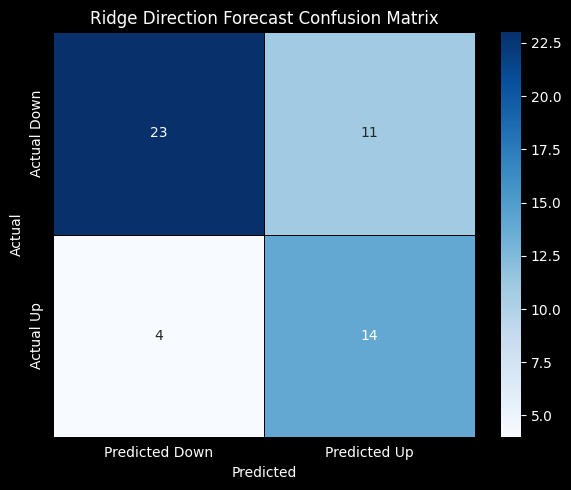

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="black"
)

plt.title("Ridge Direction Forecast Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig('directions_ridge.png',dpi=400)
plt.show()

In [116]:
coefs = model.named_steps["ridge"].coef_
features = X_train.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": coefs
}).sort_values("Importance", key=abs, ascending=False)

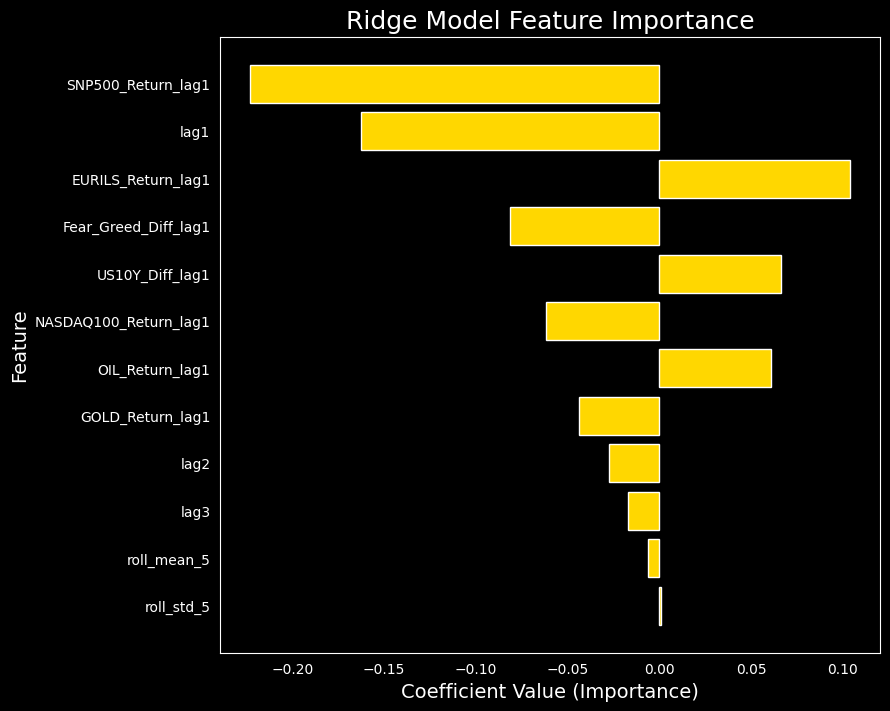

In [117]:
plt.figure(figsize=(12,8))
plt.style.use("dark_background")

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    color="#FFD700"
)

plt.title("Ridge Model Feature Importance", color="white", fontsize=18)
plt.xlabel("Coefficient Value (Importance)", color="white", fontsize=14)
plt.ylabel("Feature", color="white", fontsize=14)

plt.yticks(fontsize=10, color="white")
plt.xticks(fontsize=10, color="white")

plt.gca().invert_yaxis()
plt.grid(False)

plt.subplots_adjust(left=0.35)
plt.savefig('importance_feachers_ridge.png',dpi=400)
plt.show()

it seems a simple Ridge Model is the best model for USDILS 